# 0. Imports

In [1]:
import numpy as np
import pandas as pd
import os 
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [2]:
print(os.getcwd())
os.chdir("../")
os.getcwd()

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\notebooks


'c:\\Users\\leoco\\Documents\\cours\\M2_MOSEF\\ML_theory\\land_value_prediction'

In [3]:
import src.land_value_prediction.analyse_base_de_donnees.analyse_variable_quantitative as avqt 
import src.land_value_prediction.analyse_base_de_donnees.analyse_variable_qualitative as avql 

In [4]:
train = pd.read_parquet("data/processed/train_test_out_sample_split/idf_vf_train.parquet")
train.head()

,date_mutation,nature_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,...,commune_part_admin_sante,commune_nb_etablissements_par_menage,commune_taux_etablissements_10_plus,commune_sante_score_2013_commune,commune_education_score_2013_commune,commune_revenu_score_2013_commune,commune_idh2_2013_commune,commune_taux_criminalite_moyen,commune_taux_croissance_pop,commune_densite_pop
0,2024-09-05,Vente,215000.0,19.0,RUE JEAN JACQUES ROUSSEAU,4730,92150.0,92073,Suresnes,92,...,0.087753,0.071929,0.202652,0.694769,0.758865,0.665808,0.706481,0.421038,0.415631,13055.936675
1,2023-01-31,Vente,275000.0,72.0,RUE D AULNAY,0110,93270.0,93071,Sevran,93,...,0.122034,0.050753,0.145763,0.621656,0.311248,0.231976,0.388294,0.593598,0.750298,7106.318681
2,2021-08-25,Vente,177885.0,7.0,RUE DES CHENES,1470,92150.0,92073,Suresnes,92,...,0.087753,0.071929,0.202652,0.694769,0.758865,0.665808,0.706481,0.421038,0.102825,12734.564644
3,2021-03-12,Vente,124880.0,10.0,RUE DE LA CLOCHE,0260,77300.0,77186,Fontainebleau,77,...,0.125677,0.115469,0.145179,0.691267,0.733403,0.568990,0.664553,0.564327,0.079089,86.521360
4,2025-01-31,Vente,333100.0,10.0,RUE MIRIAM MAKEBA,6260,93500.0,93055,Pantin,93,...,0.091778,0.101081,0.200765,0.590577,0.451268,0.222436,0.421427,0.767084,1.618589,12135.728543


Supprimons les colonnes servant à construire la base mais non utiles pour la modélisation.  

In [5]:
def delete_useless_columns(df):
    
    columns_to_drop = [#valeur_fonciere, à garder pour d'éventuels analyses
                   #surface_reelle_bati, à garder pour d'éventuels analyses
                   "nature_mutation", 
                   #"adresse_nom_voie", on en a besoin pour retrouver lontitude lagitude manquantes 
                   "adresse_numero", 
                   "adresse_code_voie",                    
                   # "annee",
                   # "trimestre", # utile pour analyser les tendances saisonnières
                   "semestre_precedent", 
                   "annee_precedente", 
                   "trimestre_precedent", 
                   "commune_revenu_score_2013_commune" # redondant avec commune_revenu_median_2020
                   ]

    return df.drop(columns=columns_to_drop).copy()

print(f"Shape initiale: {train.shape}")
train = delete_useless_columns(train)
print(f"Shape après suppression des colonnes inutiles: {train.shape}")

Shape initiale: (538199, 54)
Shape après suppression des colonnes inutiles: (538199, 47)


# 1. Un peu de feature engineering

In [6]:
def do_feature_engineering(df):

    df_feat = df.copy()

    # Ratio surface/pièces (taille moyenne des pièces)
    df_feat['surface_par_piece'] = (
        df_feat['surface_reelle_bati'] / df_feat['nombre_pieces_principales']
    ).replace([np.inf, -np.inf], 0).fillna(0)
    
    # Ratio terrain/bâti (pour maisons)
    df_feat['ratio_terrain_bati'] = (
        df_feat['surface_terrain'] / df_feat['surface_reelle_bati']
    ).replace([np.inf, -np.inf], 0).fillna(0)
    
    # Log des surfaces (relations non-linéaires)
    df_feat['log_surface_bati'] = np.log1p(df_feat['surface_reelle_bati'])
    df_feat['log_surface_terrain'] = np.log1p(df_feat['surface_terrain'])
    
    # Densité (nombre de lots peut indiquer copropriété)
    df_feat['densite_lots'] = np.log1p(df_feat['nombre_lots'])
    
    # Années depuis le début (tendance temporelle)
    df_feat['nb_jours_depuis_janvier_2021'] = (df_feat['date_mutation'] - pd.Timestamp("2021-01-01")).dt.days
    
    # Distance au centre (approximatif : Paris = 48.8566, 2.3522)
    paris_lat, paris_lon = 48.8566, 2.3522
    df_feat['distance_paris'] = np.sqrt(
        (df_feat['latitude'] - paris_lat)**2 + 
        (df_feat['longitude'] - paris_lon)**2
    )
    
    # Quadrant géographique (Nord/Sud/Est/Ouest de Paris)
    df_feat['nord_paris'] = (df_feat['latitude'] > paris_lat).astype(int)
    df_feat['est_paris'] = (df_feat['longitude'] > paris_lon).astype(int)
    df_feat['sud_paris'] = (df_feat['latitude'] <= paris_lat).astype(int)
    df_feat['ouest_paris'] = (df_feat['longitude'] <= paris_lon).astype(int)
            
    
    # Prix médian × distance (l'effet du quartier peut varier avec la distance)
    df_feat['prix_median_x_distance'] = (
        df_feat['commune_prix_median_m2_semestre_prec'] * df_feat['distance_paris']
    )
    
    # Surface × type de bien (déjà encodé dans code_type_local)
    df_feat['surface_x_type'] = (
        df_feat['surface_reelle_bati'] * df_feat['code_type_local'])
    
    return df_feat 

train = do_feature_engineering(train)
train.head()

,date_mutation,valeur_fonciere,adresse_nom_voie,code_postal,code_commune,nom_commune,code_departement,nombre_lots,code_type_local,type_local,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
0,2024-09-05,215000.0,RUE JEAN JACQUES ROUSSEAU,92150.0,92073,Suresnes,92,1,1.0,Maison,...,NaN,0.693147,1343,0.133461,1,0,0,1,967.016044,26.0
1,2023-01-31,275000.0,RUE D AULNAY,93270.0,93071,Sevran,93,0,1.0,Maison,...,6.293419,0.000000,760,0.183752,1,1,0,0,586.598160,61.0
2,2021-08-25,177885.0,RUE DES CHENES,92150.0,92073,Suresnes,92,1,2.0,Appartement,...,NaN,0.693147,236,0.134611,1,0,0,1,1021.514369,52.0
3,2021-03-12,124880.0,RUE DE LA CLOCHE,77300.0,77186,Fontainebleau,77,2,2.0,Appartement,...,NaN,1.098612,70,0.569855,0,1,1,0,2587.141694,62.0
4,2025-01-31,333100.0,RUE MIRIAM MAKEBA,93500.0,93055,Pantin,93,1,2.0,Appartement,...,NaN,0.693147,1491,0.082451,1,1,0,0,486.251134,124.0


# 2. Typage des variables 

In [7]:
train

,date_mutation,valeur_fonciere,adresse_nom_voie,code_postal,code_commune,nom_commune,code_departement,nombre_lots,code_type_local,type_local,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
0,2024-09-05,215000.0,RUE JEAN JACQUES ROUSSEAU,92150.0,92073,Suresnes,92,1,1.0,Maison,...,NaN,0.693147,1343,0.133461,1,0,0,1,967.016044,26.0
1,2023-01-31,275000.0,RUE D AULNAY,93270.0,93071,Sevran,93,0,1.0,Maison,...,6.293419,0.000000,760,0.183752,1,1,0,0,586.598160,61.0
2,2021-08-25,177885.0,RUE DES CHENES,92150.0,92073,Suresnes,92,1,2.0,Appartement,...,NaN,0.693147,236,0.134611,1,0,0,1,1021.514369,52.0
3,2021-03-12,124880.0,RUE DE LA CLOCHE,77300.0,77186,Fontainebleau,77,2,2.0,Appartement,...,NaN,1.098612,70,0.569855,0,1,1,0,2587.141694,62.0
4,2025-01-31,333100.0,RUE MIRIAM MAKEBA,93500.0,93055,Pantin,93,1,2.0,Appartement,...,NaN,0.693147,1491,0.082451,1,1,0,0,486.251134,124.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538194,2024-08-27,290000.0,AV DE BALZAC,91420.0,91432,Morangis,91,1,2.0,Appartement,...,NaN,0.693147,1334,0.155852,0,0,1,1,547.513411,110.0
538195,2024-11-07,1234325.0,RUE CHASSELOUP LAUBAT,75015.0,75115,Paris 15e Arrondissement,75,1,2.0,Appartement,...,NaN,0.693147,1406,0.048400,0,0,1,1,463.037633,164.0
538196,2021-01-29,340000.0,AV DE PARIS,94800.0,94076,Villejuif,94,1,2.0,Appartement,...,NaN,0.693147,28,0.057468,0,1,1,0,323.034317,120.0
538197,2022-09-26,384000.0,RUE DES POIRIERS BLANCS,77580.0,77142,Crécy-la-Chapelle,77,0,1.0,Maison,...,6.111467,0.000000,633,0.551927,1,1,0,0,1692.574841,103.0


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538199 entries, 0 to 538198
Data columns (total 60 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   date_mutation                                    538199 non-null  datetime64[ns]
 1   valeur_fonciere                                  538199 non-null  float64       
 2   adresse_nom_voie                                 538198 non-null  object        
 3   code_postal                                      538198 non-null  float64       
 4   code_commune                                     538199 non-null  object        
 5   nom_commune                                      538199 non-null  object        
 6   code_departement                                 538199 non-null  object        
 7   nombre_lots                                      538199 non-null  int64         
 8   code_type_local         

In [9]:
def cast_variables(df):
    
    # Cast des colonnes spécifiques en category
    for col in ["code_postal", "code_type_local", "commune_revenu_median_2020", "ouest_paris", "sud_paris", "est_paris", "nord_paris"]:
        if col in df.columns:
            df[col] = df[col].astype('category')
        else:
            print(f"{col} n'est pas dans les colonnes du dataframe")

    # Cast des colonnes object en category
    for col in df.select_dtypes(include='object').columns:
        if df[col].nunique() > 300:
            print(f"La colonne {col} a trop de modalités ({df[col].nunique()}) pour être castée en 'category'.")
            continue  # Skip cette colonne
        df[col] = df[col].astype('category')

    # Cast des colonnes numériques
    for col in df.select_dtypes(include=np.number).columns:
        # Vérifier si la colonne contient des décimales
        if df[col].dtype in ['float64', 'float32'] and not (df[col] % 1 == 0).all():
            df[col] = df[col].astype('float32')
            continue
            
        if df[col].min() >= 0:
            if df[col].max() <= 255:
                df[col] = df[col].astype('uint8')
            elif df[col].max() <= 65535:
                df[col] = df[col].astype('uint16')
            elif df[col].max() <= 4294967295:
                df[col] = df[col].astype('uint32')
            else:
                df[col] = df[col].astype('float32')
        else:
            if df[col].min() >= -128 and df[col].max() <= 127:
                df[col] = df[col].astype('int8')
            elif df[col].min() >= -32768 and df[col].max() <= 32767:
                df[col] = df[col].astype('int16')
            elif df[col].min() >= -2147483648 and df[col].max() <= 2147483647:
                df[col] = df[col].astype('int32')
            else:
                df[col] = df[col].astype('float32')
            
    return df.copy()

train = cast_variables(train)
train

La colonne adresse_nom_voie a trop de modalités (39301) pour être castée en 'category'.
La colonne code_commune a trop de modalités (1286) pour être castée en 'category'.
La colonne nom_commune a trop de modalités (1282) pour être castée en 'category'.


,date_mutation,valeur_fonciere,adresse_nom_voie,code_postal,code_commune,nom_commune,code_departement,nombre_lots,code_type_local,type_local,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
0,2024-09-05,215000.0,RUE JEAN JACQUES ROUSSEAU,92150.0,92073,Suresnes,92,1,1.0,Maison,...,NaN,0.693147,1343,0.133461,1,0,0,1,967.016052,26
1,2023-01-31,275000.0,RUE D AULNAY,93270.0,93071,Sevran,93,0,1.0,Maison,...,6.293419,0.000000,760,0.183752,1,1,0,0,586.598145,61
2,2021-08-25,177885.0,RUE DES CHENES,92150.0,92073,Suresnes,92,1,2.0,Appartement,...,NaN,0.693147,236,0.134611,1,0,0,1,1021.514343,52
3,2021-03-12,124880.0,RUE DE LA CLOCHE,77300.0,77186,Fontainebleau,77,2,2.0,Appartement,...,NaN,1.098612,70,0.569855,0,1,1,0,2587.141602,62
4,2025-01-31,333100.0,RUE MIRIAM MAKEBA,93500.0,93055,Pantin,93,1,2.0,Appartement,...,NaN,0.693147,1491,0.082451,1,1,0,0,486.251129,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538194,2024-08-27,290000.0,AV DE BALZAC,91420.0,91432,Morangis,91,1,2.0,Appartement,...,NaN,0.693147,1334,0.155852,0,0,1,1,547.513428,110
538195,2024-11-07,1234325.0,RUE CHASSELOUP LAUBAT,75015.0,75115,Paris 15e Arrondissement,75,1,2.0,Appartement,...,NaN,0.693147,1406,0.048400,0,0,1,1,463.037628,164
538196,2021-01-29,340000.0,AV DE PARIS,94800.0,94076,Villejuif,94,1,2.0,Appartement,...,NaN,0.693147,28,0.057468,0,1,1,0,323.034302,120
538197,2022-09-26,384000.0,RUE DES POIRIERS BLANCS,77580.0,77142,Crécy-la-Chapelle,77,0,1.0,Maison,...,6.111467,0.000000,633,0.551927,1,1,0,0,1692.574829,103


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538199 entries, 0 to 538198
Data columns (total 60 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   date_mutation                                    538199 non-null  datetime64[ns]
 1   valeur_fonciere                                  538199 non-null  float32       
 2   adresse_nom_voie                                 538198 non-null  object        
 3   code_postal                                      538198 non-null  category      
 4   code_commune                                     538199 non-null  object        
 5   nom_commune                                      538199 non-null  object        
 6   code_departement                                 538199 non-null  category      
 7   nombre_lots                                      538199 non-null  uint8         
 8   code_type_local         

# 3. Analyse des variables numériques  

In [11]:
train.select_dtypes(include=np.number).columns.tolist()

['valeur_fonciere',
 'nombre_lots',
 'surface_reelle_bati',
 'nombre_pieces_principales',
 'surface_terrain',
 'longitude',
 'latitude',
 'annee',
 'prix_m2',
 'commune_prix_median_m2_semestre_prec',
 'ecart_prix_median_pct',
 'commune_etablissements_agriculture_2021',
 'commune_etablissements_industrie_2021',
 'commune_etablissements_construction_2021',
 'commune_etablissements_1_salarie_2021',
 'commune_etablissements_10_plus_salaries_2021',
 'commune_densite_population_active_2020',
 'commune_taux_residences_secondaires',
 'commune_taux_logements_vacants',
 'commune_taux_proprietaires',
 'commune_ratio_residences_secondaires_population',
 'commune_densite_residences_principales_2020',
 'commune_taux_chomage_15_64',
 'commune_taux_emploi',
 'commune_evolution_emploi_2014_2020',
 'commune_part_services_entreprises',
 'commune_part_commerce_tourisme',
 'commune_part_admin_sante',
 'commune_nb_etablissements_par_menage',
 'commune_taux_etablissements_10_plus',
 'commune_sante_score_2013

#### Statistiques descriptives 

In [12]:
train.select_dtypes(include=np.number).describe()

,valeur_fonciere,nombre_lots,surface_reelle_bati,nombre_pieces_principales,surface_terrain,longitude,latitude,annee,prix_m2,commune_prix_median_m2_semestre_prec,...,commune_densite_pop,surface_par_piece,ratio_terrain_bati,log_surface_bati,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,prix_median_x_distance,surface_x_type
count,5.381990e+05,538199.000000,538199.000000,538199.000000,175120.000000,531283.000000,531283.000000,538199.000000,538199.000000,528702.000000,...,538199.000000,538199.000000,538199.000000,538199.000000,175120.000000,538199.000000,538199.000000,531283.000000,521929.000000,538199.000000
mean,3.939878e+05,1.086810,71.888892,3.227643,576.100708,2.360422,48.828705,2022.518344,6003.199707,5825.210449,...,9724.690430,22.361229,2.224816,4.133402,5.914274,0.625180,731.162693,0.216658,862.236877,109.775299
std,3.524557e+05,0.968757,42.955576,1.550885,1805.761841,0.249955,0.144410,1.269153,3653.826416,2981.649414,...,10193.700195,6.796077,14.462414,0.568562,0.832528,0.480035,458.882919,0.192968,500.273132,55.278761
min,5.200000e+03,0.000000,10.000000,1.000000,1.000000,1.453111,48.125164,2021.000000,500.239990,729.927002,...,3.012685,1.000000,0.000000,2.397895,0.693147,0.000000,0.000000,0.001141,14.924404,10.000000
25%,1.950000e+05,0.000000,42.000000,2.000000,240.000000,2.248712,48.786373,2021.000000,3255.785767,3506.276611,...,2026.453735,18.333334,0.000000,3.761200,5.484797,0.000000,333.000000,0.075172,493.582214,72.000000
50%,3.000000e+05,1.000000,65.000000,3.000000,401.000000,2.343398,48.853973,2022.000000,4764.706055,4480.500000,...,5768.778320,21.250000,0.000000,4.189655,5.996452,0.693147,665.000000,0.158758,753.771790,100.000000
75%,4.600000e+05,2.000000,90.000000,4.000000,550.000000,2.468547,48.904114,2024.000000,8214.286133,7760.984375,...,13995.297852,25.000000,2.470117,4.510859,6.311735,1.098612,1116.000000,0.293253,1111.045166,136.000000
max,1.050000e+07,23.000000,880.000000,15.000000,448021.000000,3.518413,49.234760,2025.000000,19998.888672,19335.511719,...,39957.222656,375.000000,5270.835449,6.781058,13.012598,3.178054,1641.000000,1.190886,15262.631836,1392.000000


#### Cartes de visualisation des prix 

In [13]:
# Filtrer les données avec des coordonnées valides
train_map = train.dropna(subset=['longitude', 'latitude', 'prix_m2']).sample(frac=0.1, random_state=42)  # Échantillonner pour performance

# Créer la carte interactive avec plotly et une échelle de couleur plus progressive
fig = px.density_map(
    train_map, 
    lat='latitude', 
    lon='longitude', 
    z='prix_m2',
    radius=8,
    center=dict(lat=48.8566, lon=2.3522),
    zoom=8.5,
    # color_continuous_scale='Viridis',  
    range_color=[train_map['prix_m2'].quantile(0.05), train_map['prix_m2'].quantile(0.95)],  # Meilleure répartition
    labels={'prix_m2': 'Prix au m² (€)'},
    title='Carte interactive des prix au m² en Île-de-France',
    height=700
)

fig.update_traces(opacity=0.6)

fig.update_layout(
    mapbox_style="open-street-map",
    font=dict(size=12),
    title_font=dict(size=16, family='Arial Black'),
    coloraxis_colorbar=dict(title="Prix au m² (€)")
)

fig.show()

In [14]:
# Calculer le prix médian par commune
prix_par_commune = train.groupby(['code_commune', 'nom_commune']).agg({
    'prix_m2': 'median',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

# Supprimer les valeurs manquantes
prix_par_commune = prix_par_commune.dropna(subset=['longitude', 'latitude', 'prix_m2'])

# Créer la carte avec agrégation par commune
# Créer des bins de 250 euros pour une échelle de couleur progressive
prix_min = prix_par_commune['prix_m2'].quantile(0.05)
prix_max = prix_par_commune['prix_m2'].quantile(0.95)
n_bins = int((prix_max - prix_min) / 250)

fig = px.scatter_map(
    prix_par_commune,
    lat='latitude',
    lon='longitude',
    color='prix_m2',
    size='prix_m2',
    hover_name='nom_commune',
    hover_data={'prix_m2': ':.0f', 'latitude': False, 'longitude': False},
    color_continuous_scale='Turbo',
    range_color=[prix_min, prix_max],
    color_continuous_midpoint=(prix_min + prix_max) / 2,
    size_max=20,
    zoom=8.5,
    center=dict(lat=48.8566, lon=2.3522),
    title='Prix médian au m² par commune en Île-de-France',
    labels={'prix_m2': 'Prix médian au m² (€)'},
    height=700
)

fig.update_layout(
    mapbox_style="open-street-map",
    font=dict(size=12),
    title_font=dict(size=16, family='Arial Black'),
    coloraxis_colorbar=dict(title="Prix médian au m² (€)")
)

fig.show()

#### Valeurs manquantes 

In [15]:
round(train.isnull().mean() * 100, 2)

date_mutation                                       0.00
valeur_fonciere                                     0.00
adresse_nom_voie                                    0.00
code_postal                                         0.00
code_commune                                        0.00
nom_commune                                         0.00
code_departement                                    0.00
nombre_lots                                         0.00
code_type_local                                     0.00
type_local                                          0.00
surface_reelle_bati                                 0.00
nombre_pieces_principales                           0.00
surface_terrain                                    67.46
longitude                                           1.29
latitude                                            1.29
annee                                               0.00
semestre                                            0.00
trimestre                      

##### 1) Surface terrain 

In [16]:
train[train['surface_terrain'].isnull()]["code_postal"].value_counts(normalize=True).round(2) * 100

code_postal
75015.0    3.0
75018.0    3.0
75017.0    3.0
75011.0    2.0
75016.0    2.0
          ... 
77171.0    0.0
77157.0    0.0
77880.0    0.0
77134.0    0.0
77145.0    0.0
Name: proportion, Length: 526, dtype: float64

In [17]:
train[train['surface_terrain'] == 0].shape

(0, 60)

In [18]:
train["type_local"].value_counts(normalize=True).round(2) * 100

type_local
Appartement    68.0
Maison         32.0
Name: proportion, dtype: float64

In [19]:
train[train['surface_terrain'].isnull()]["type_local"].value_counts(normalize=True).round(2) * 100

type_local
Appartement    96.0
Maison          4.0
Name: proportion, dtype: float64

Si la surface terrain est manquante cela veut sûrement dire que le bien immobilier n'est pas associé à un terrain (ex: Paris intra muros).  On voit que ce sont très souvent des appartements. On va mettre à zéro les surfaces de terrain:

In [20]:
def fill_missing_surface_terrain(df):
    df['surface_terrain'] = df['surface_terrain'].fillna(0)
    return df.copy()

train = fill_missing_surface_terrain(train)
train

,date_mutation,valeur_fonciere,adresse_nom_voie,code_postal,code_commune,nom_commune,code_departement,nombre_lots,code_type_local,type_local,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
0,2024-09-05,215000.0,RUE JEAN JACQUES ROUSSEAU,92150.0,92073,Suresnes,92,1,1.0,Maison,...,NaN,0.693147,1343,0.133461,1,0,0,1,967.016052,26
1,2023-01-31,275000.0,RUE D AULNAY,93270.0,93071,Sevran,93,0,1.0,Maison,...,6.293419,0.000000,760,0.183752,1,1,0,0,586.598145,61
2,2021-08-25,177885.0,RUE DES CHENES,92150.0,92073,Suresnes,92,1,2.0,Appartement,...,NaN,0.693147,236,0.134611,1,0,0,1,1021.514343,52
3,2021-03-12,124880.0,RUE DE LA CLOCHE,77300.0,77186,Fontainebleau,77,2,2.0,Appartement,...,NaN,1.098612,70,0.569855,0,1,1,0,2587.141602,62
4,2025-01-31,333100.0,RUE MIRIAM MAKEBA,93500.0,93055,Pantin,93,1,2.0,Appartement,...,NaN,0.693147,1491,0.082451,1,1,0,0,486.251129,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538194,2024-08-27,290000.0,AV DE BALZAC,91420.0,91432,Morangis,91,1,2.0,Appartement,...,NaN,0.693147,1334,0.155852,0,0,1,1,547.513428,110
538195,2024-11-07,1234325.0,RUE CHASSELOUP LAUBAT,75015.0,75115,Paris 15e Arrondissement,75,1,2.0,Appartement,...,NaN,0.693147,1406,0.048400,0,0,1,1,463.037628,164
538196,2021-01-29,340000.0,AV DE PARIS,94800.0,94076,Villejuif,94,1,2.0,Appartement,...,NaN,0.693147,28,0.057468,0,1,1,0,323.034302,120
538197,2022-09-26,384000.0,RUE DES POIRIERS BLANCS,77580.0,77142,Crécy-la-Chapelle,77,0,1.0,Maison,...,6.111467,0.000000,633,0.551927,1,1,0,0,1692.574829,103


##### 2) Retrouver un proxy de lattitude et longitude 

In [21]:
train[train['latitude'].isnull()]

,date_mutation,valeur_fonciere,adresse_nom_voie,code_postal,code_commune,nom_commune,code_departement,nombre_lots,code_type_local,type_local,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
45,2023-01-20,190000.0,RUE JULES CHATENAY,93380.0,93059,Pierrefitte-sur-Seine,93,1,2.0,Appartement,...,NaN,0.693147,749,NaN,0,0,0,0,NaN,178
80,2022-07-04,490000.0,RUE DE BORDEAUX,95400.0,95019,Arnouville,95,0,1.0,Maison,...,6.326149,0.000000,549,NaN,0,0,0,0,NaN,98
171,2022-06-28,350000.0,AV ROGER SALENGRO,92370.0,92022,Chaville,92,1,2.0,Appartement,...,NaN,0.693147,543,NaN,0,0,0,0,NaN,98
430,2022-04-15,494950.0,CHE DU CLOS DU ROI,91530.0,91630,Le Val-Saint-Germain,91,0,1.0,Maison,...,6.216606,0.000000,469,NaN,0,0,0,0,NaN,102
641,2023-09-27,470000.0,AV DES MYOSOTIS,93370.0,93047,Montfermeil,93,0,1.0,Maison,...,6.802395,0.000000,999,NaN,0,0,0,0,NaN,106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537921,2021-06-30,590000.0,ALL SUZANNE,92160.0,92002,Antony,92,0,1.0,Maison,...,5.918894,0.000000,180,NaN,0,0,0,0,NaN,117
537933,2021-02-19,166000.0,ALL DES PEUPLIERS,95350.0,95539,Saint-Brice-sous-Forêt,95,2,2.0,Appartement,...,NaN,1.098612,49,NaN,0,0,0,0,NaN,160
538039,2021-01-13,190000.0,RUE GABRIELLE JOSSERAND,93500.0,93055,Pantin,93,2,2.0,Appartement,...,NaN,1.098612,12,NaN,0,0,0,0,NaN,92
538057,2023-06-28,100000.0,RES LE PARC DE PETIT BOURG,91000.0,91228,Évry-Courcouronnes,91,2,2.0,Appartement,...,NaN,1.098612,908,NaN,0,0,0,0,NaN,134


##### 3) Commune prix médian 

On va devoir retrouver le prix médian dans un cercle géographique défini. 

##### 4) Indicateurs communaux : commune_idh2_2013_commune, commune_taux_criminalite_moyen, revenu médian de la commune 

In [22]:
train["commune_densite_pop"] = train["commune_densite_pop"].astype('float64')

In [23]:
train[train["commune_revenu_median_2020"].isnull()][ "commune_densite_pop"].describe()

count    58.000000
mean     16.650999
std       8.466015
min       3.012685
25%      10.209713
50%      15.513330
75%      22.302158
max      31.355932
Name: commune_densite_pop, dtype: float64

Ce sont des villages pour lesquels les données de revenu médian ne sont pas disponibles. Il faudrait recouper avec les villages d'à côté. 

In [24]:
train[train["commune_idh2_2013_commune"].isnull()]["nom_commune"].value_counts()

nom_commune
Mulcent                 8
Chatignonville          8
Menouville              6
Vulaines-lès-Provins    5
Obsonville              5
Le Plessis-Gassot       4
Passy-sur-Seine         4
Vaudherland             4
Épinay-Champlâtreux     3
Garentreville           3
Montenils               3
Sigy                    3
Theuville               2
Bois-Herpin             2
Gambaiseuil             2
Le Tartre-Gaudran       2
Roinvilliers            2
Châtenay-en-France      1
Name: count, dtype: int64

Ces 18 villages n'ont pas fait partie de l'étude où on récupère les données visiblement. 

In [25]:
train[train["commune_taux_criminalite_moyen"].isnull()]["nom_commune"].value_counts()

nom_commune
Pierrefitte-sur-Seine    759
Gouzangrez                 4
Name: count, dtype: int64

In [26]:
train[train["commune_taux_croissance_pop"].isnull()][["nom_commune", "code_commune"]]

,nom_commune,code_commune


In [27]:
train[train["commune_densite_pop"].isnull()]["nom_commune"].value_counts()

Series([], Name: count, dtype: int64)

#### Analyse des distributions 

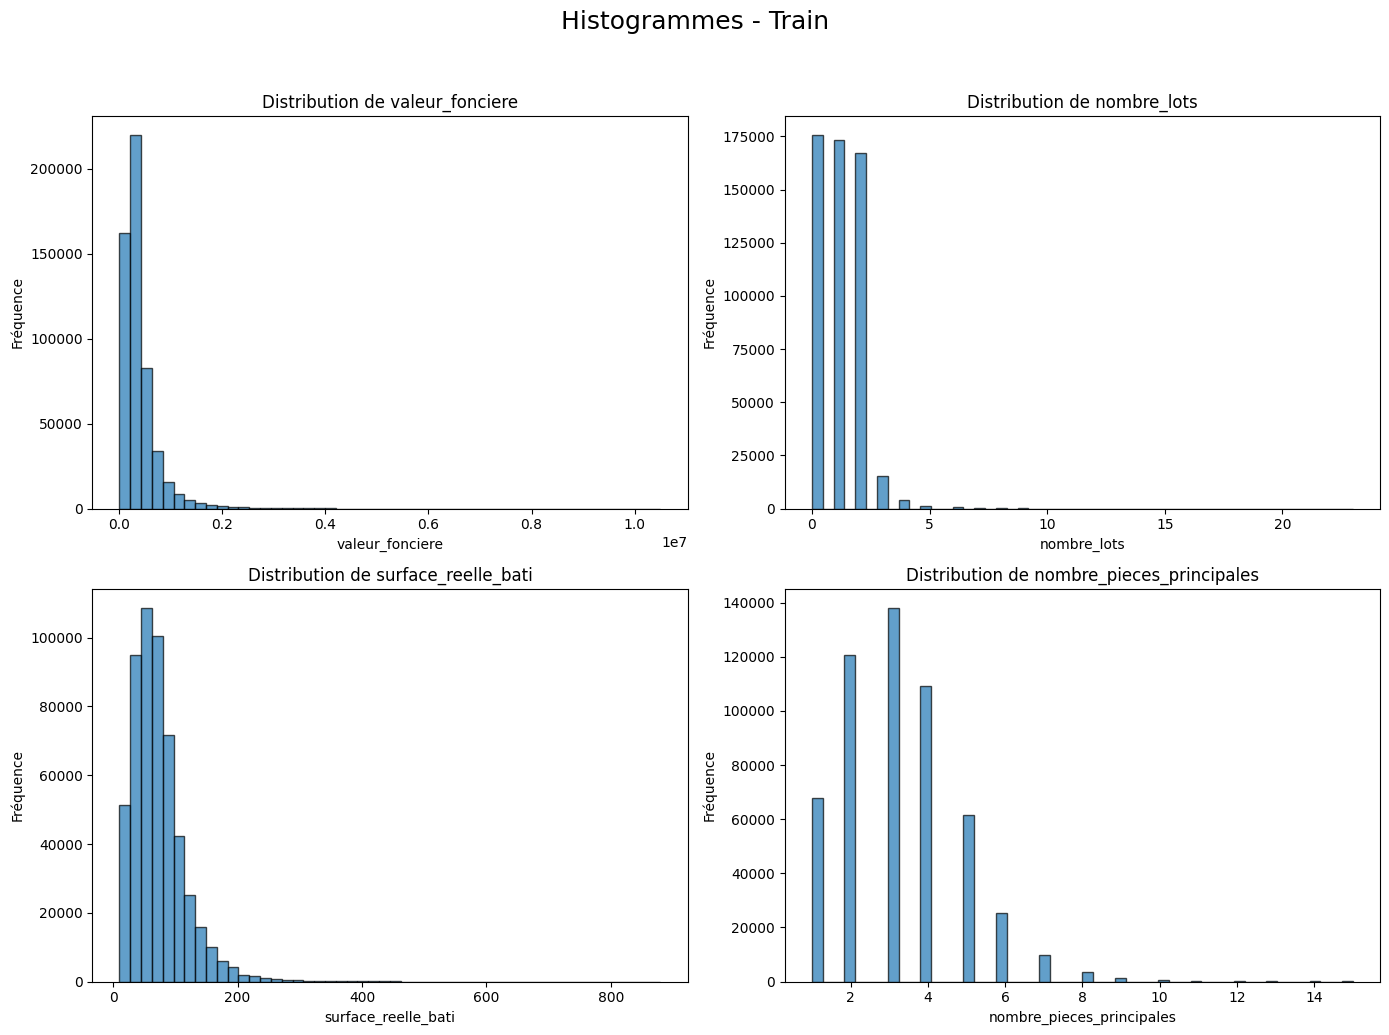

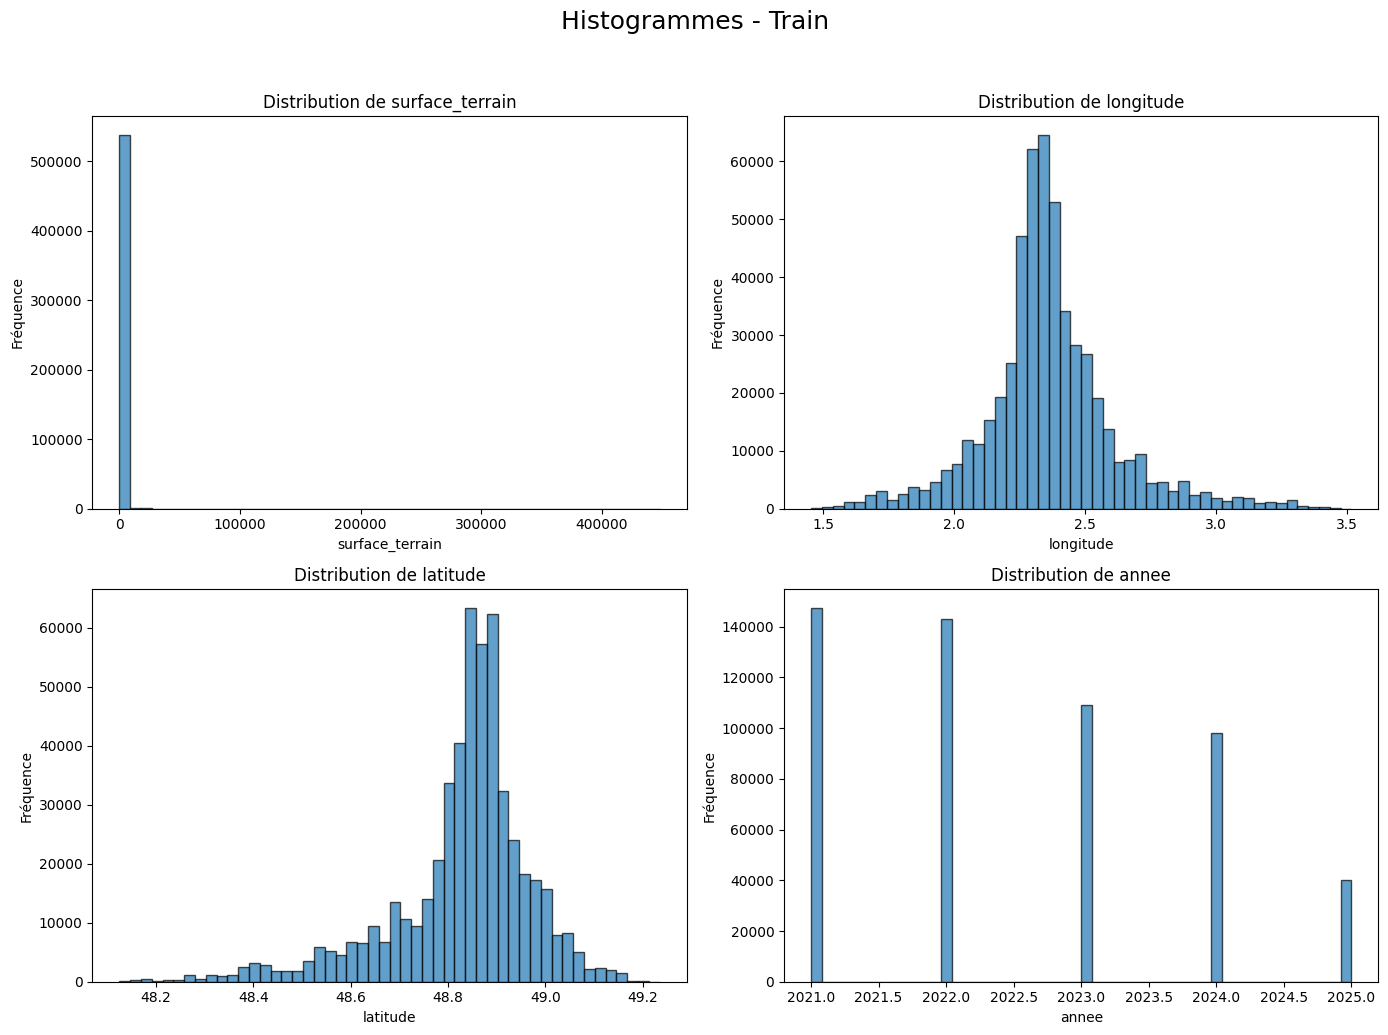

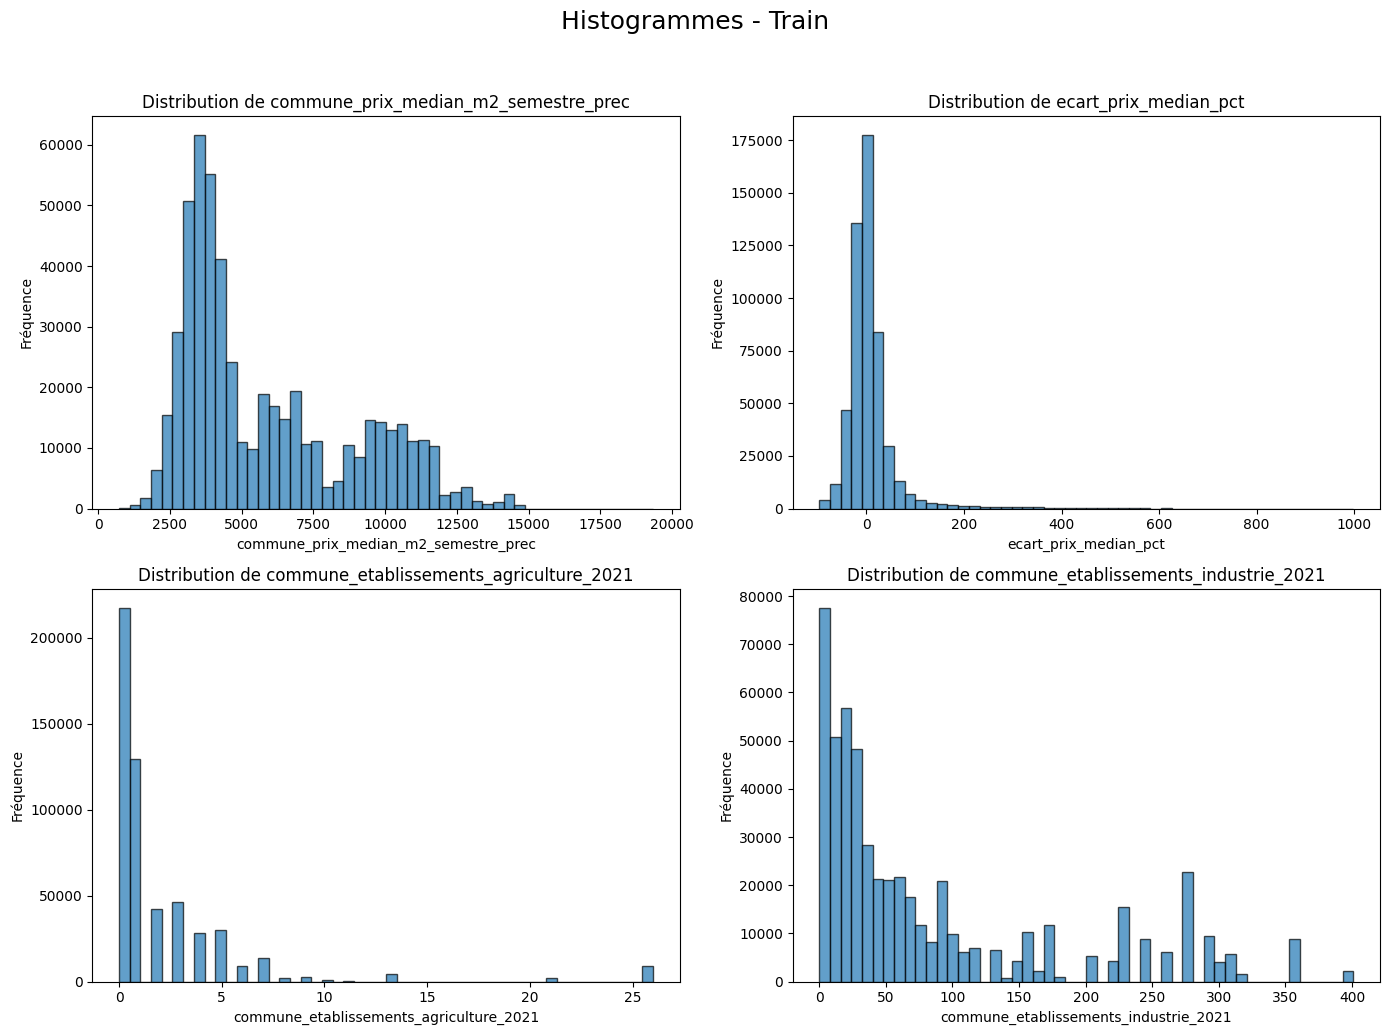

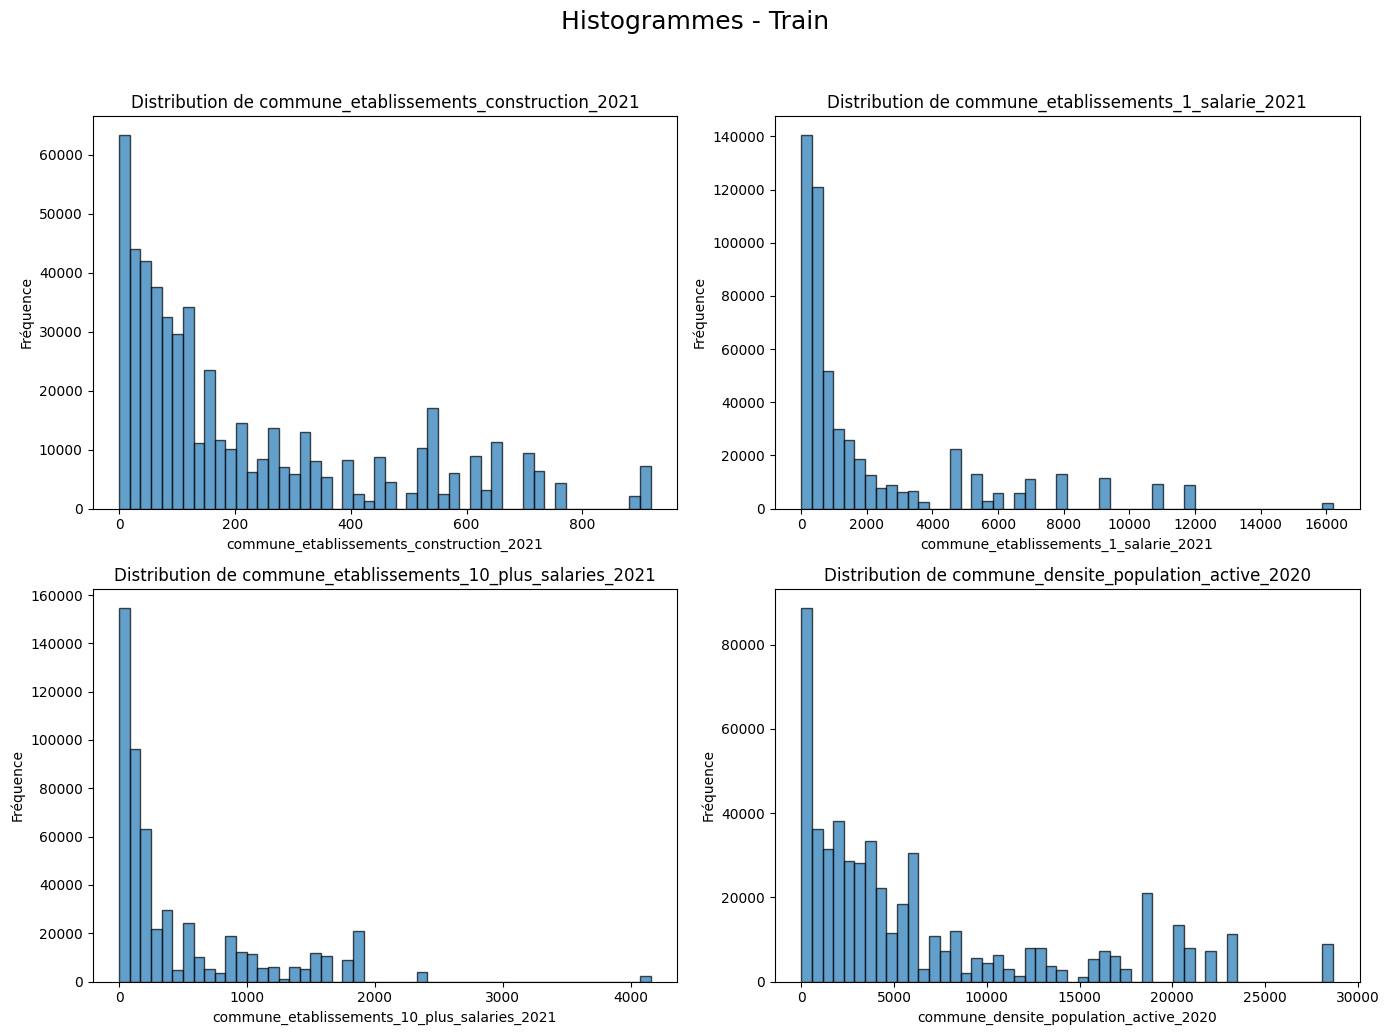

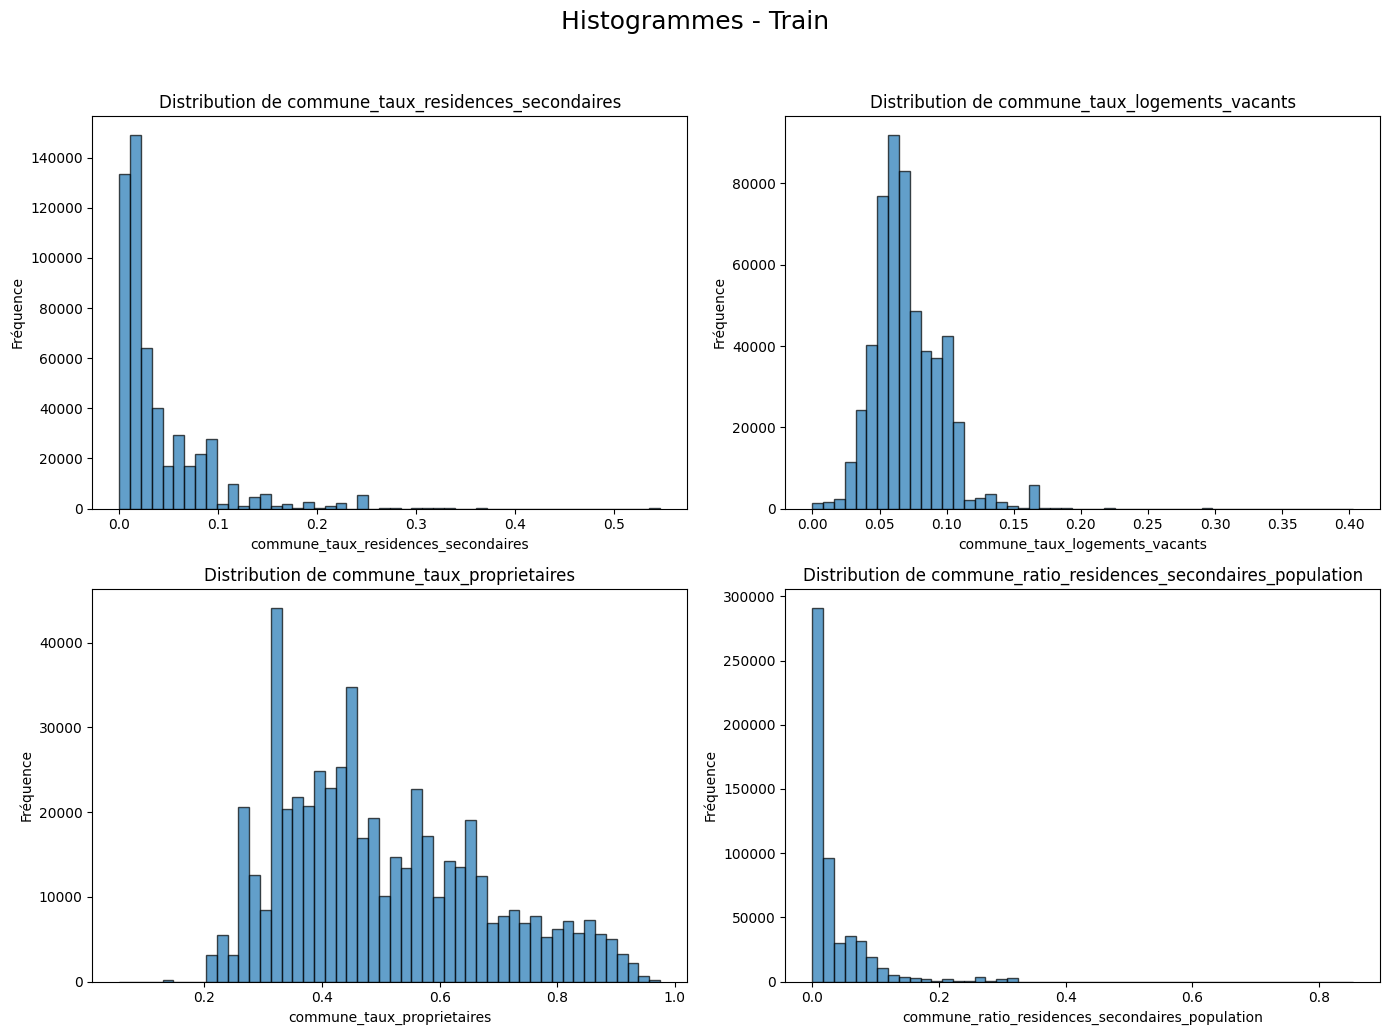

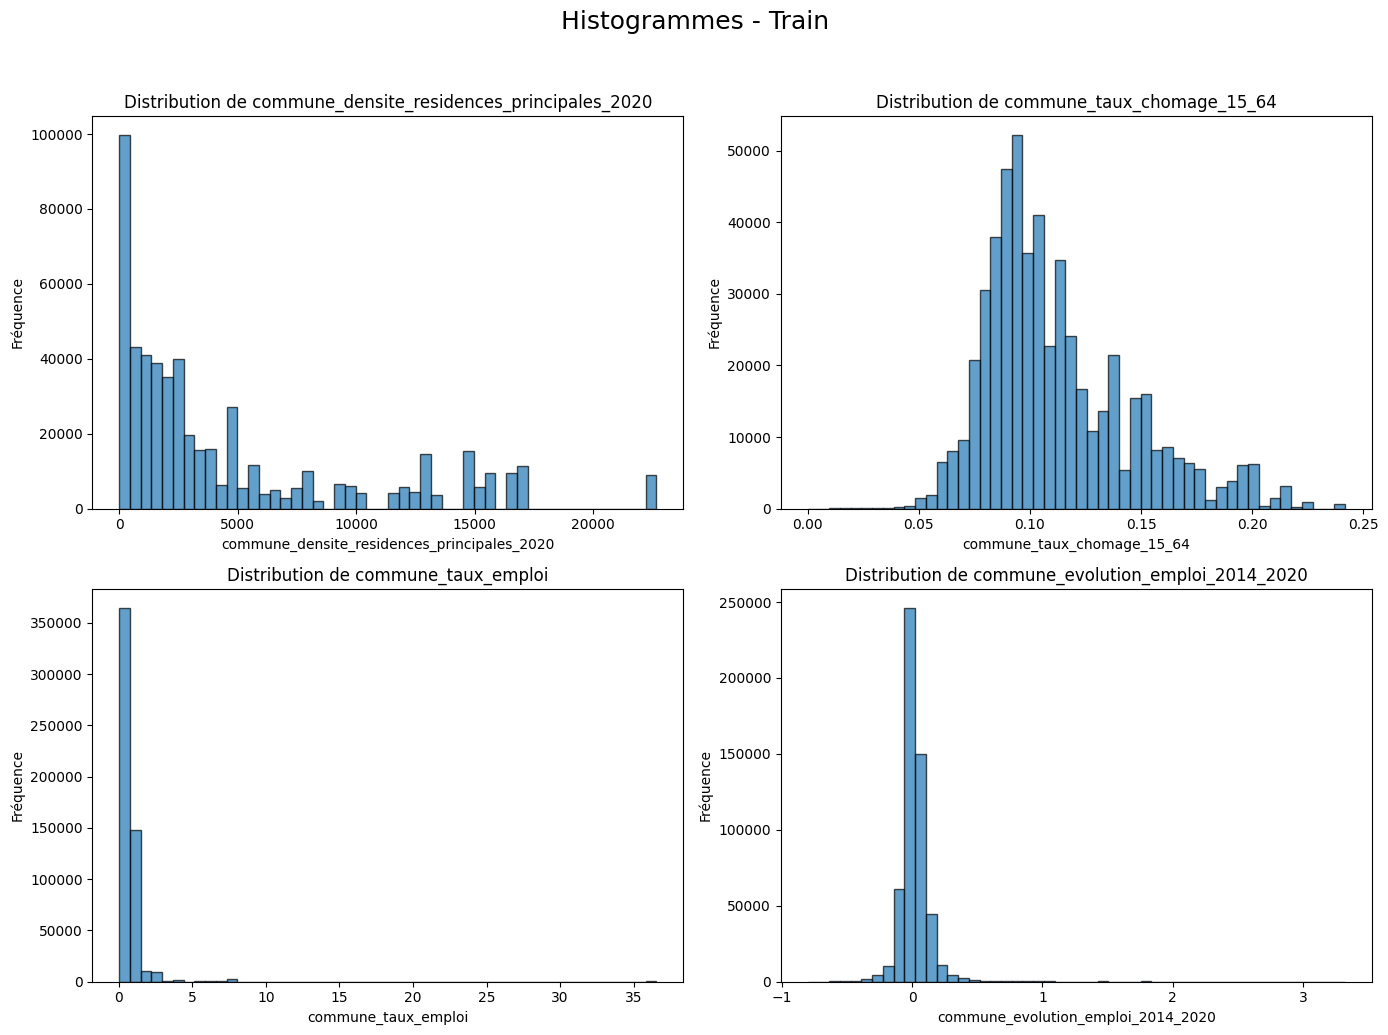

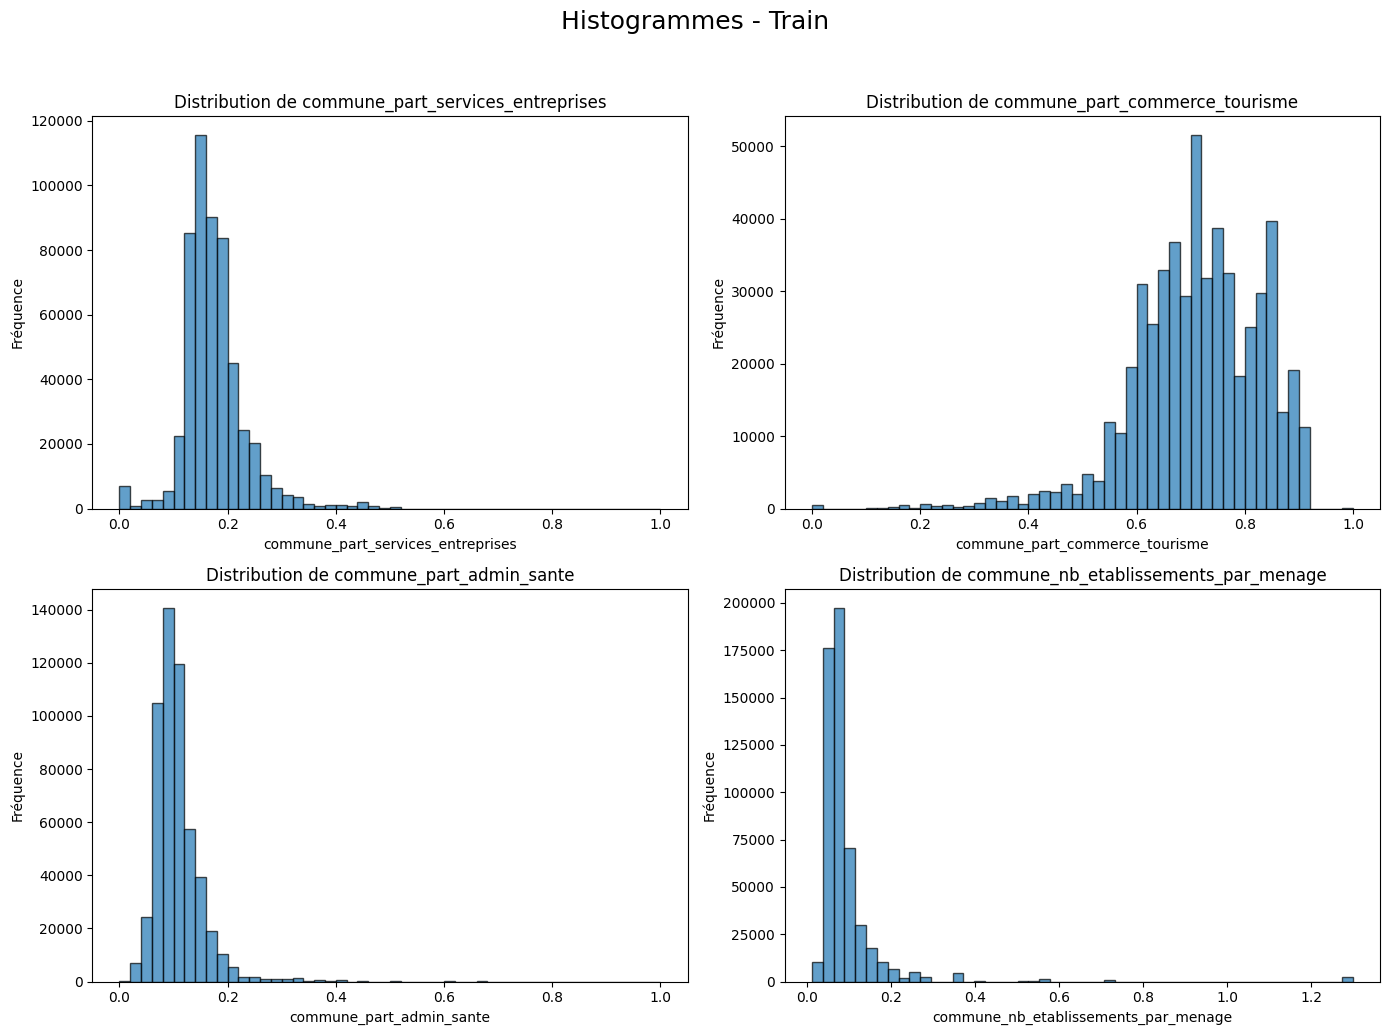

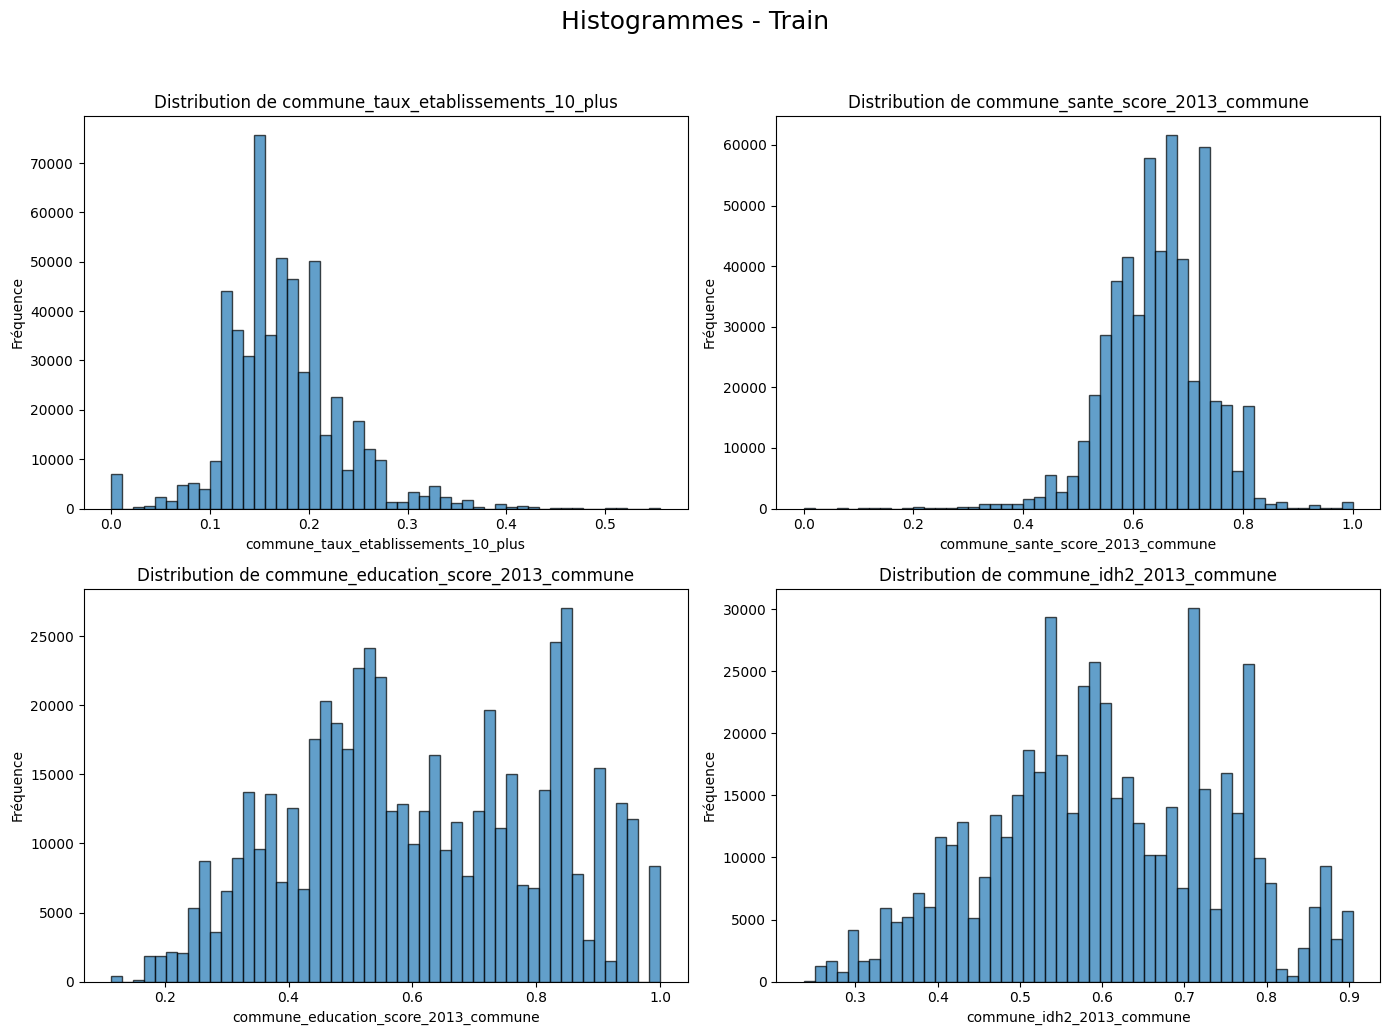

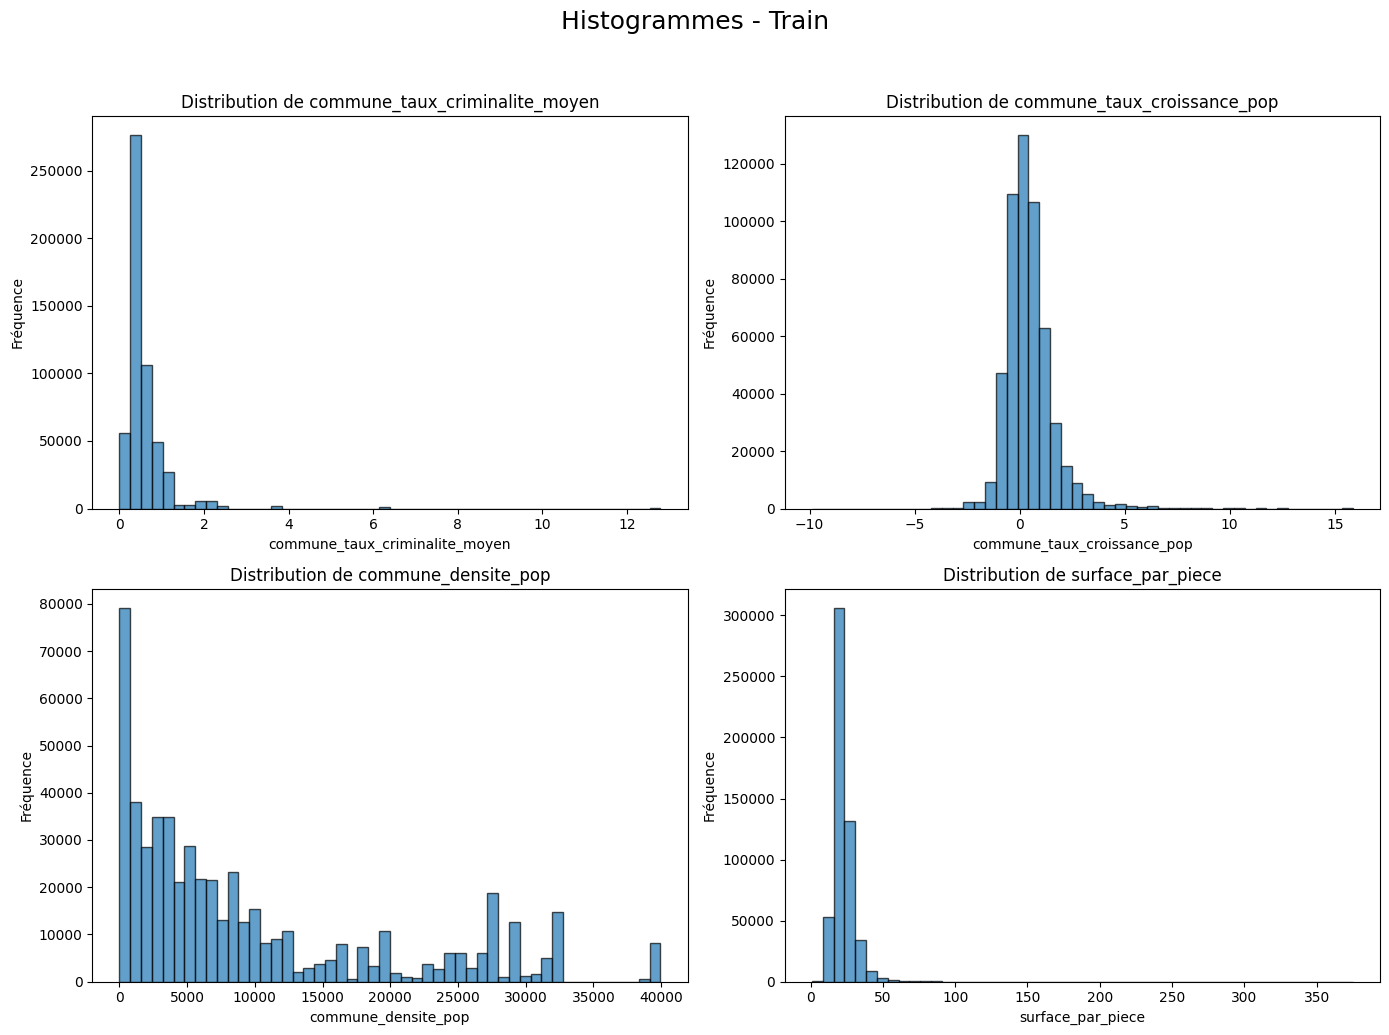

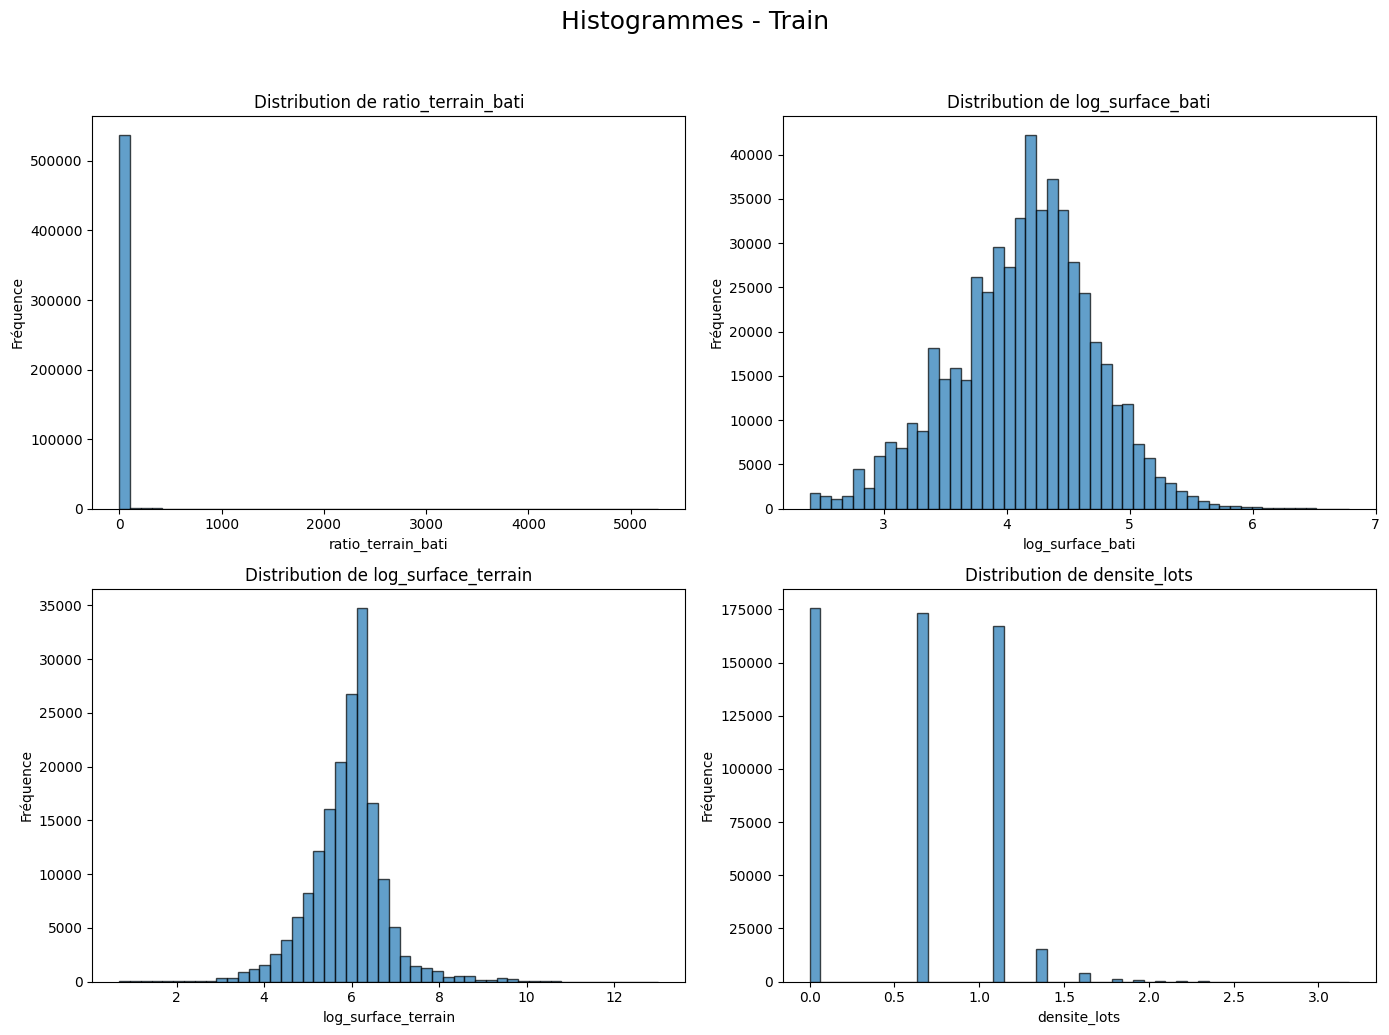

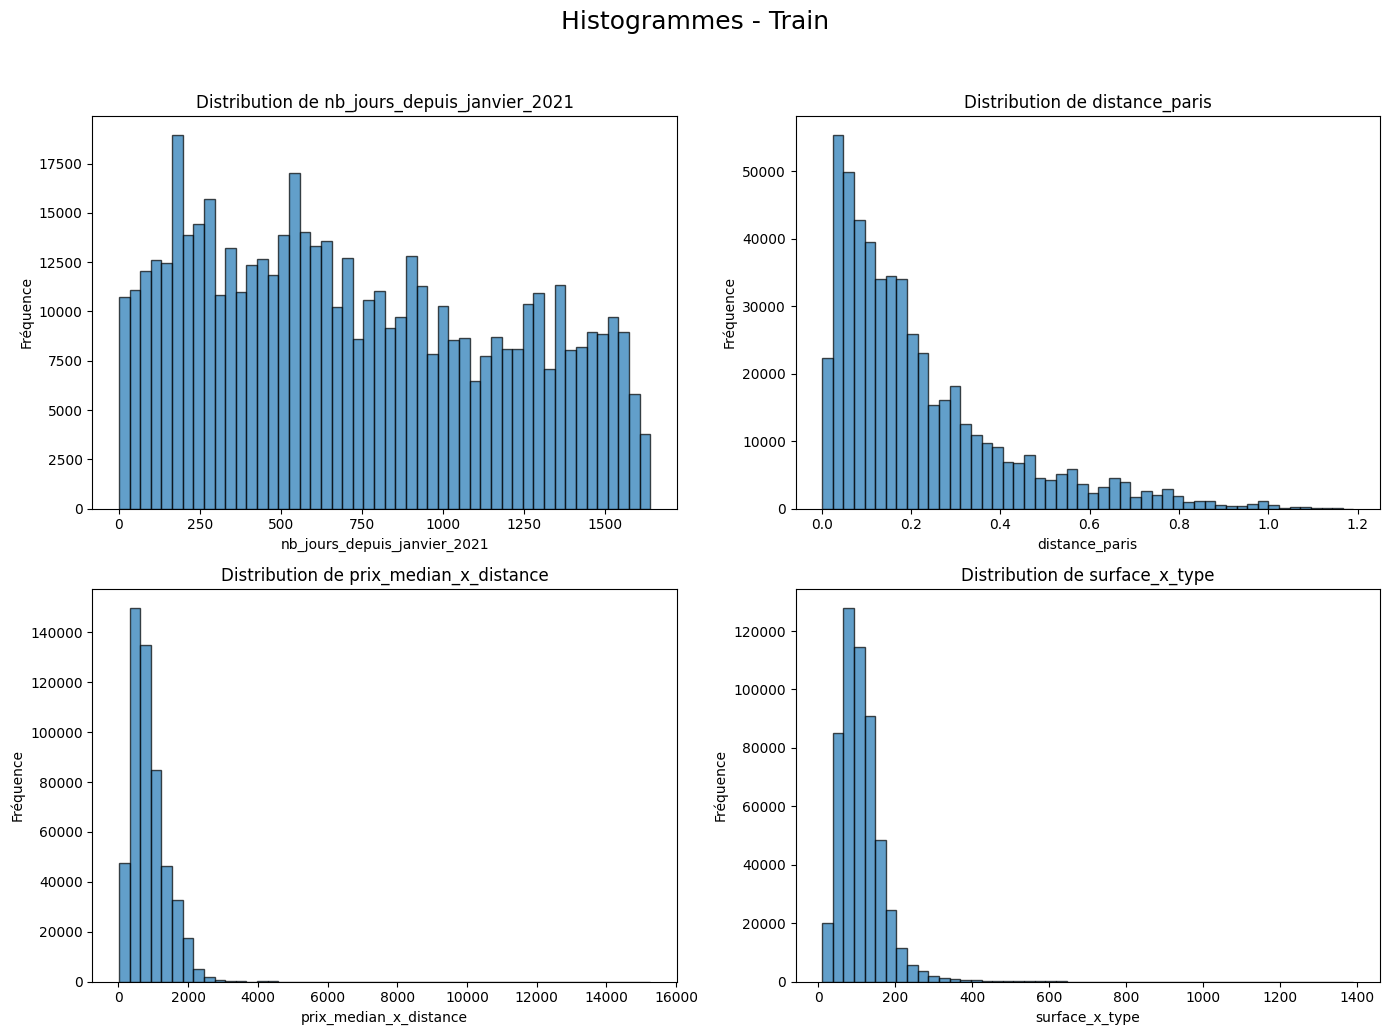

In [28]:
avqt.visualiser_par_batch(train.drop("prix_m2", axis=1), 
                          train["prix_m2"], 
                          [col for col in train.select_dtypes(include=np.number).columns.tolist() if col != "prix_m2"], 
                          avqt.plot_histogramme, 
                          "Histogrammes - Train")

#### Valeurs aberrantes

In [29]:
def zscore_outlier_rate(df, threshold=3):
    """
    Calcule le taux de valeurs aberrantes (outliers) pour chaque variable numérique
    selon le critère du z-score (> threshold ou < -threshold).
    Retourne un DataFrame avec le taux d'outliers par variable et les seuils min/max.
    """
    numeric_cols = df.select_dtypes(include=np.number).columns
    outlier_stats = {}
    for col in numeric_cols:
        mean = df[col].mean()
        std = df[col].std(ddof=0)
        col_zscore = (df[col] - mean) / std
        outlier_mask = col_zscore.abs() > threshold
        outlier_rate = outlier_mask.mean() * 100  # en pourcentage
        lower_bound = mean - threshold * std
        upper_bound = mean + threshold * std
        outlier_stats[col] = {
            'outlier_rate_%': outlier_rate,
            'outlier_min': lower_bound,
            'outlier_max': upper_bound
        }
    return pd.DataFrame.from_dict(outlier_stats, orient='index').sort_values('outlier_rate_%', ascending=False)

outliers_df = zscore_outlier_rate(train.drop("prix_m2", axis=1), threshold=3)
outliers_df

,outlier_rate_%,outlier_min,outlier_max
commune_part_services_entreprises,2.805839,0.002369,3.455131e-01
commune_taux_residences_secondaires,2.289674,-0.094824,1.733551e-01
commune_taux_etablissements_10_plus,2.210521,0.001158,3.477646e-01
commune_ratio_residences_secondaires_population,2.145303,-0.112515,1.817408e-01
commune_etablissements_agriculture_2021,2.034378,-9.834820,1.412208e+01
commune_etablissements_1_salarie_2021,2.034378,-6919.030273,1.115050e+04
valeur_fonciere,1.940360,-663378.125000,1.451354e+06
ecart_prix_median_pct,1.901713,-156.525482,1.709478e+02
longitude,1.780568,1.610559,3.110286e+00
latitude,1.698814,48.395473,4.926194e+01


#### Boxplots 

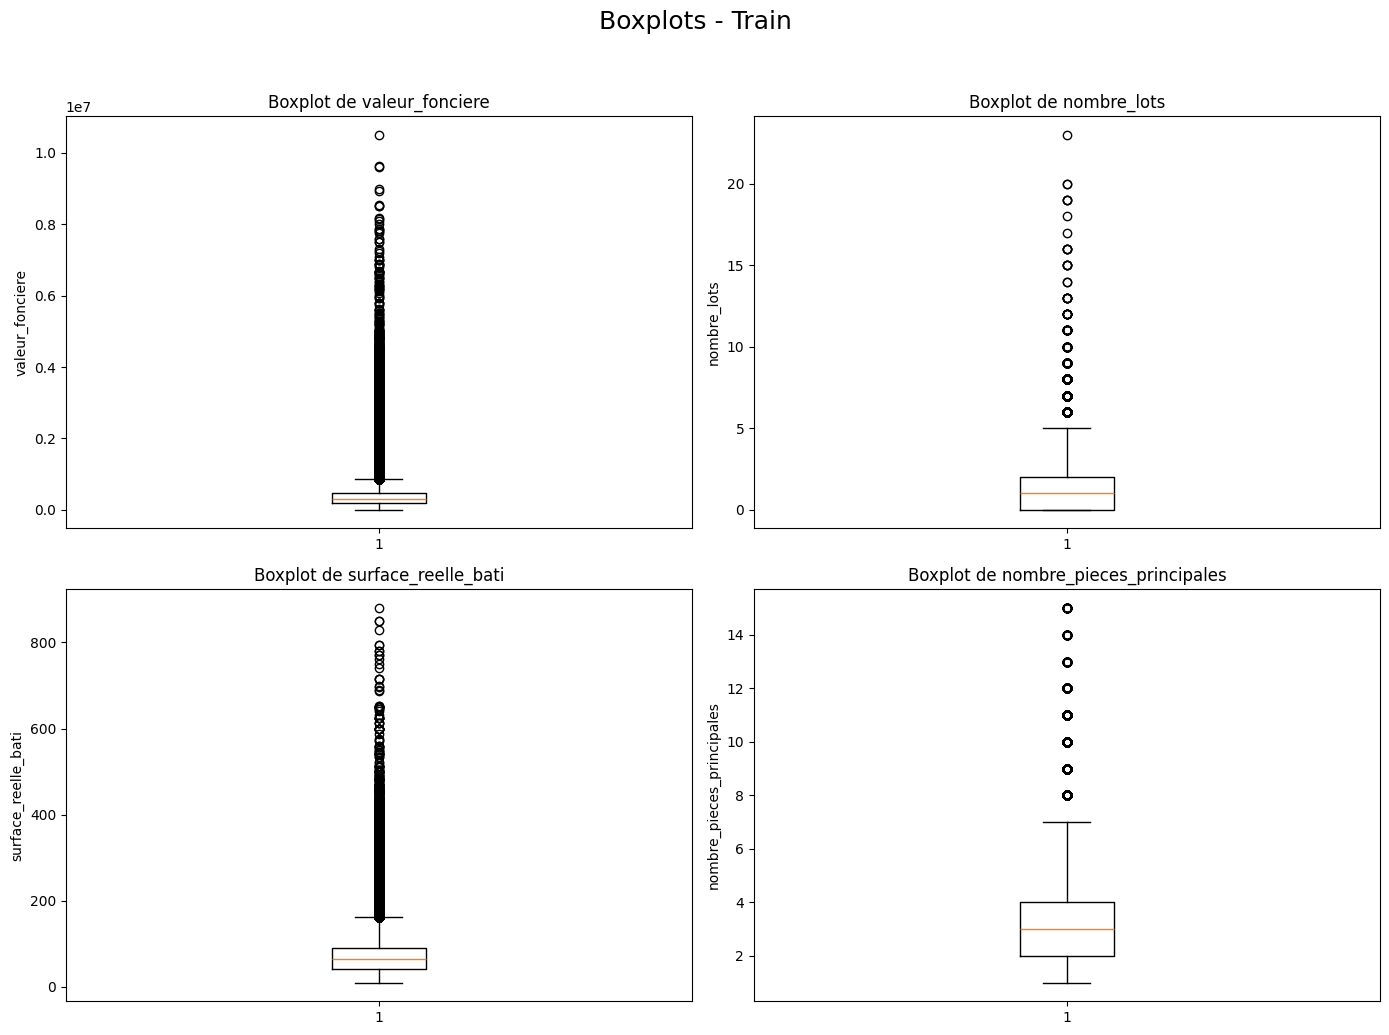

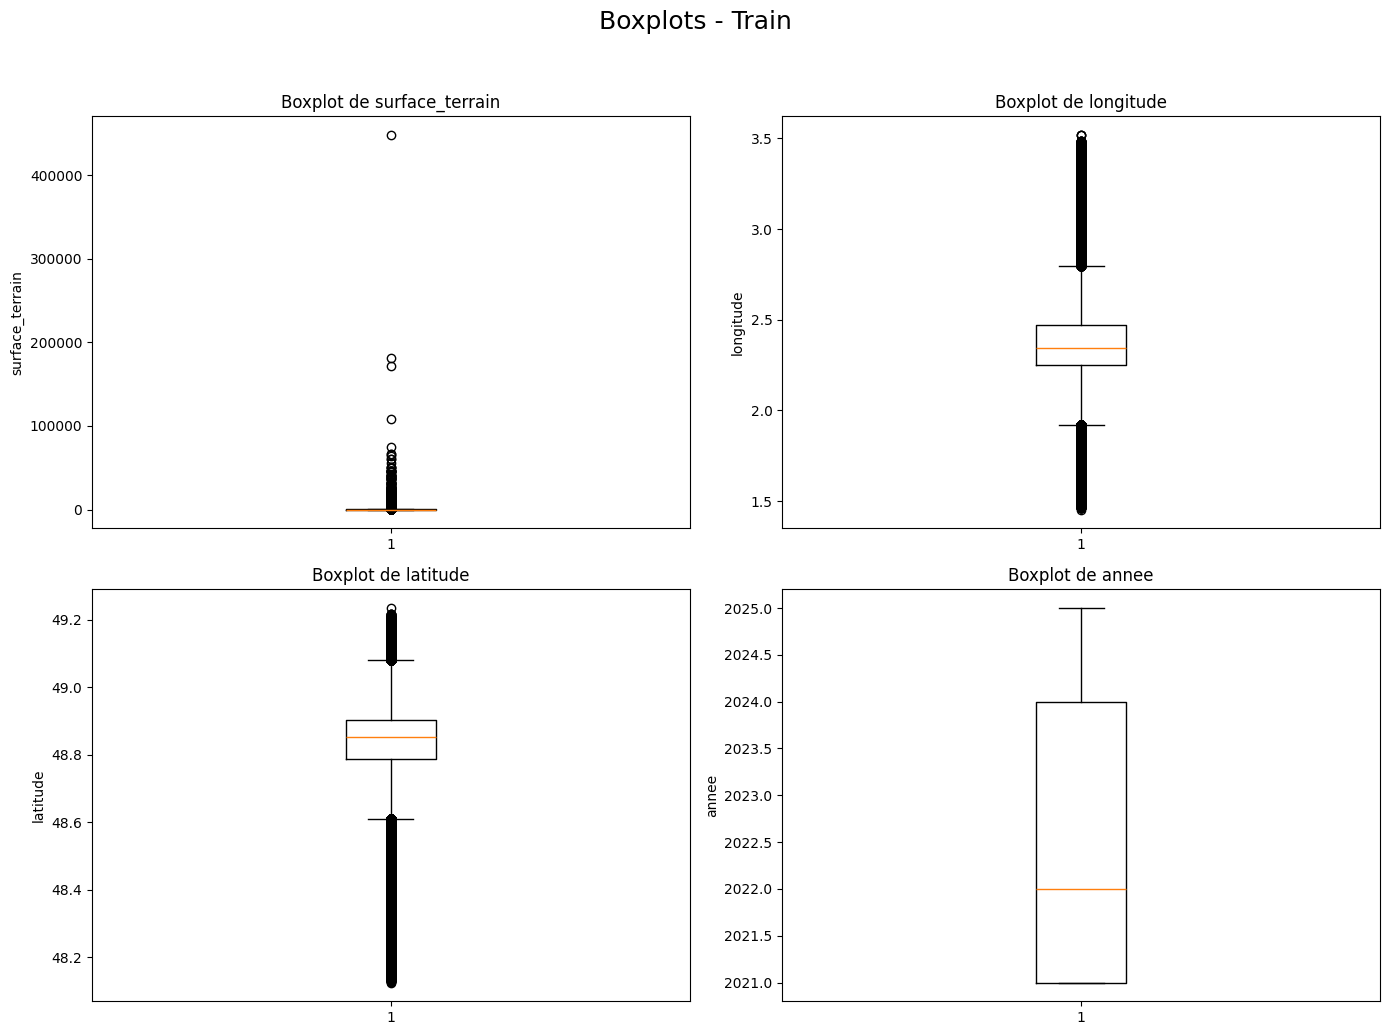

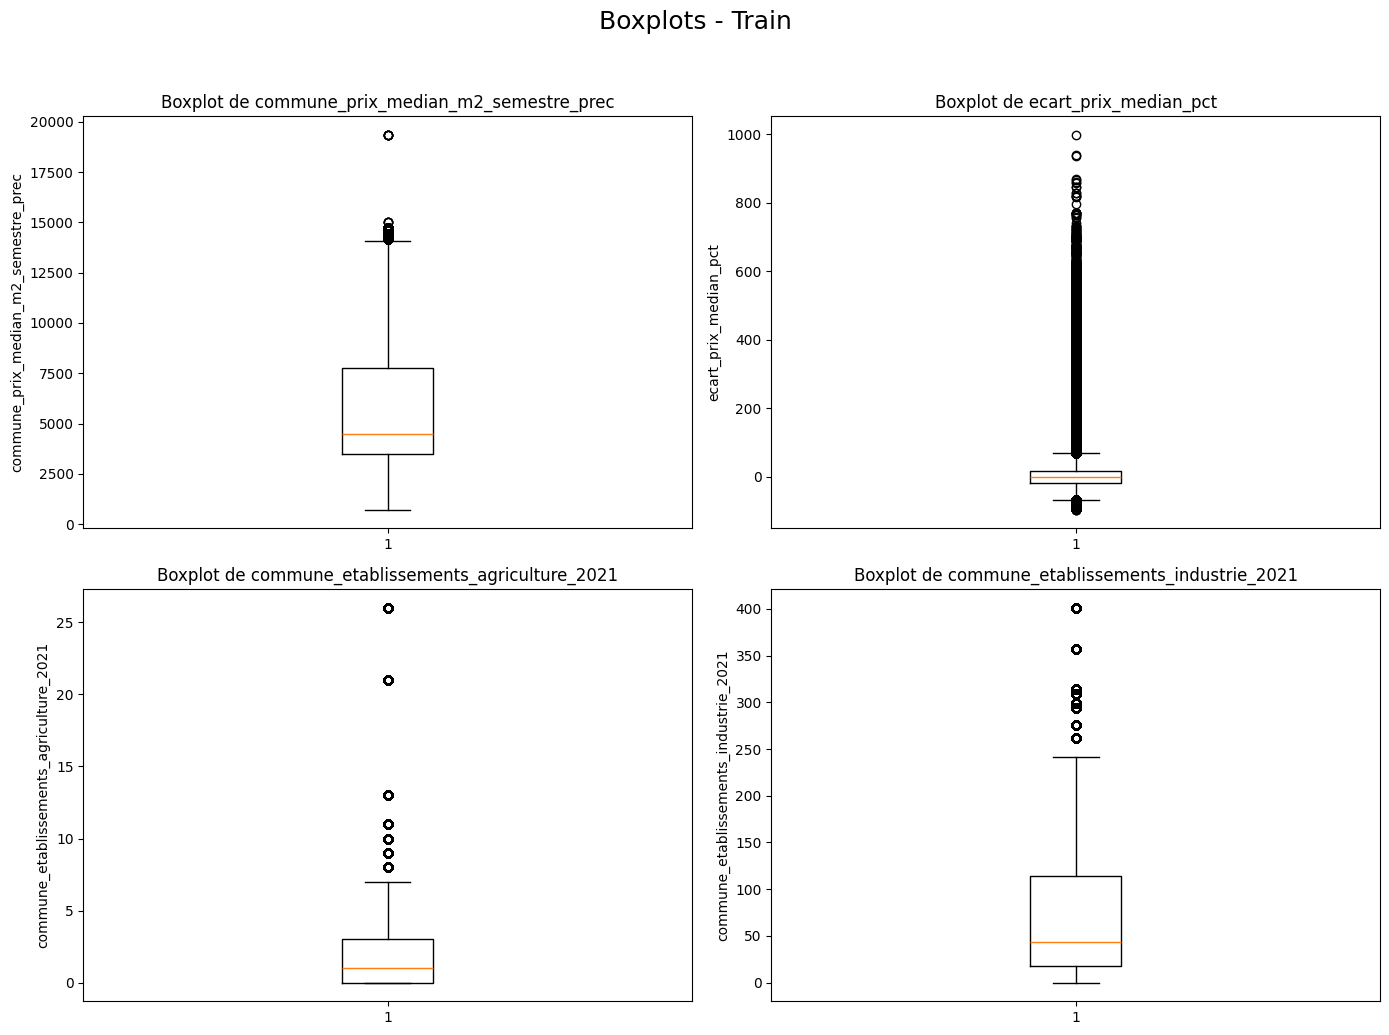

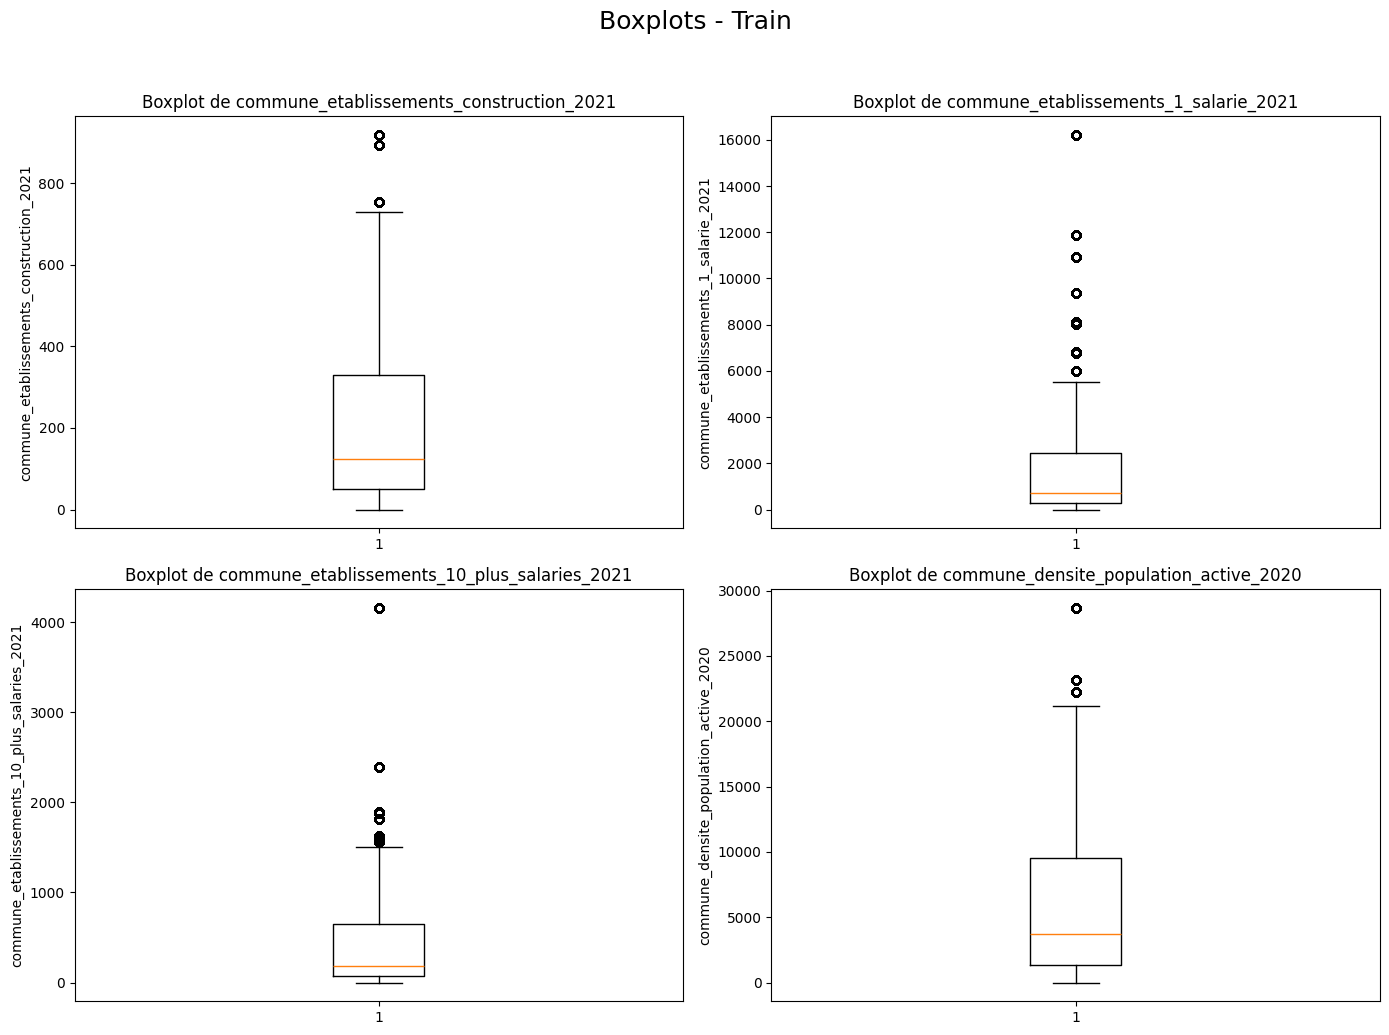

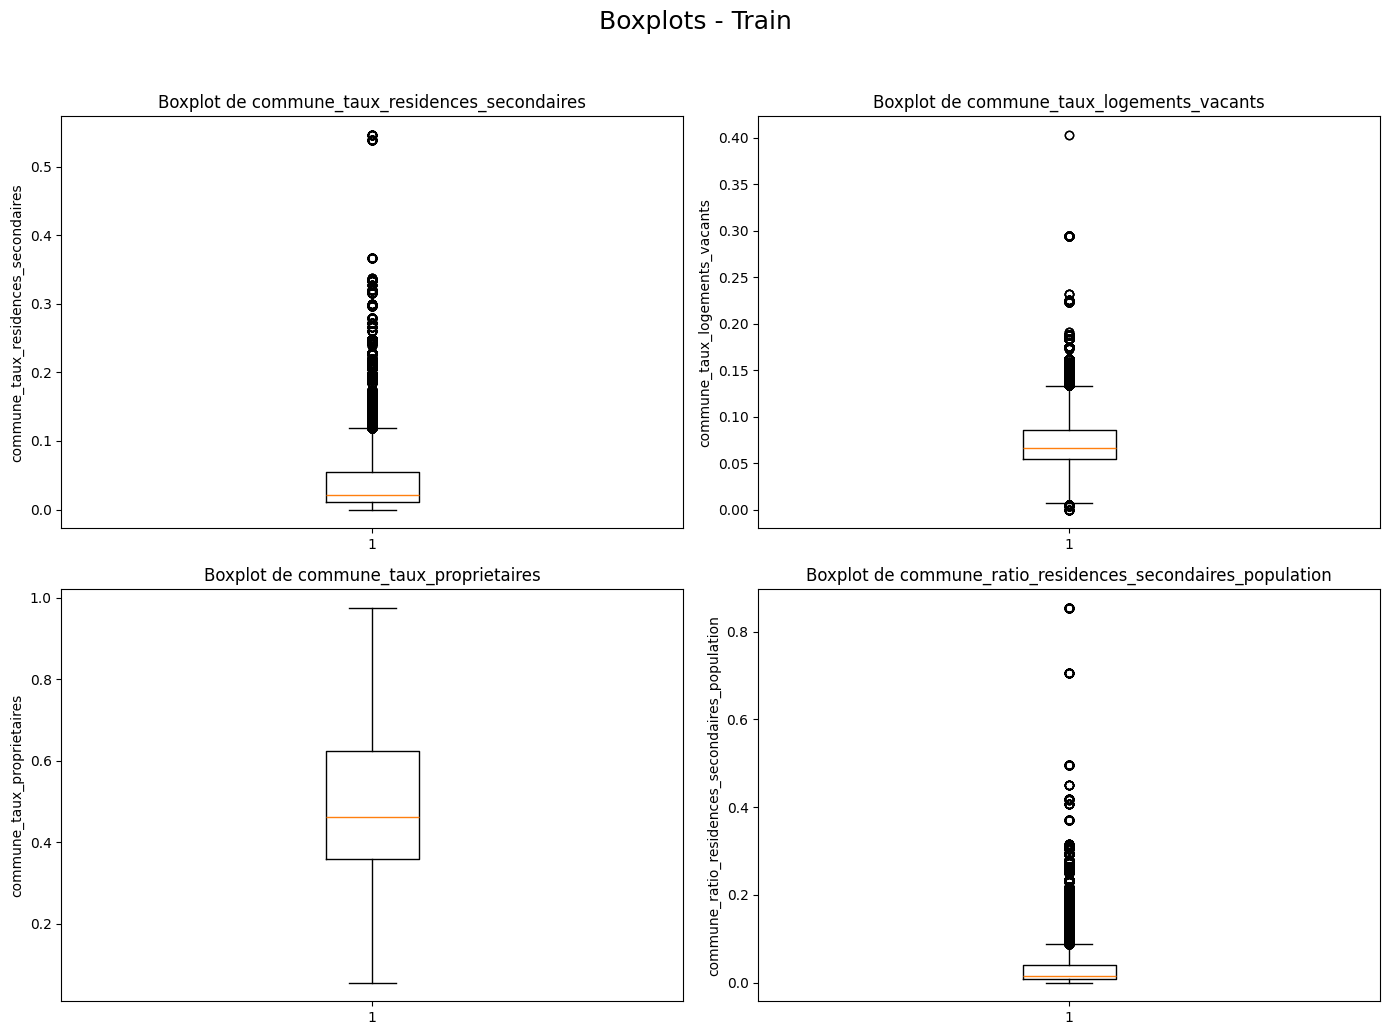

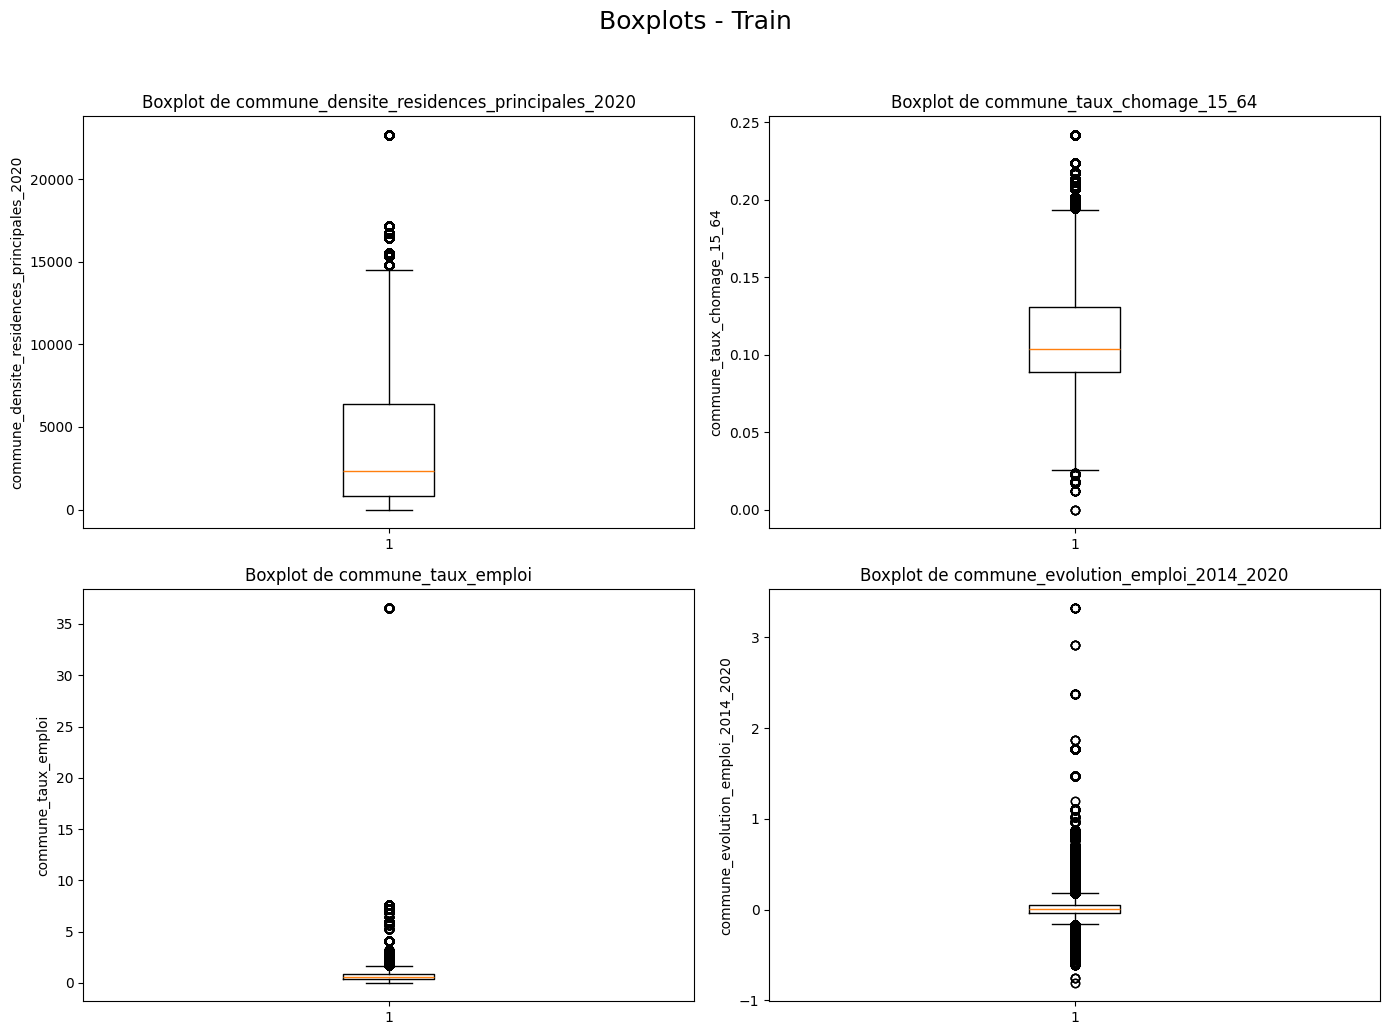

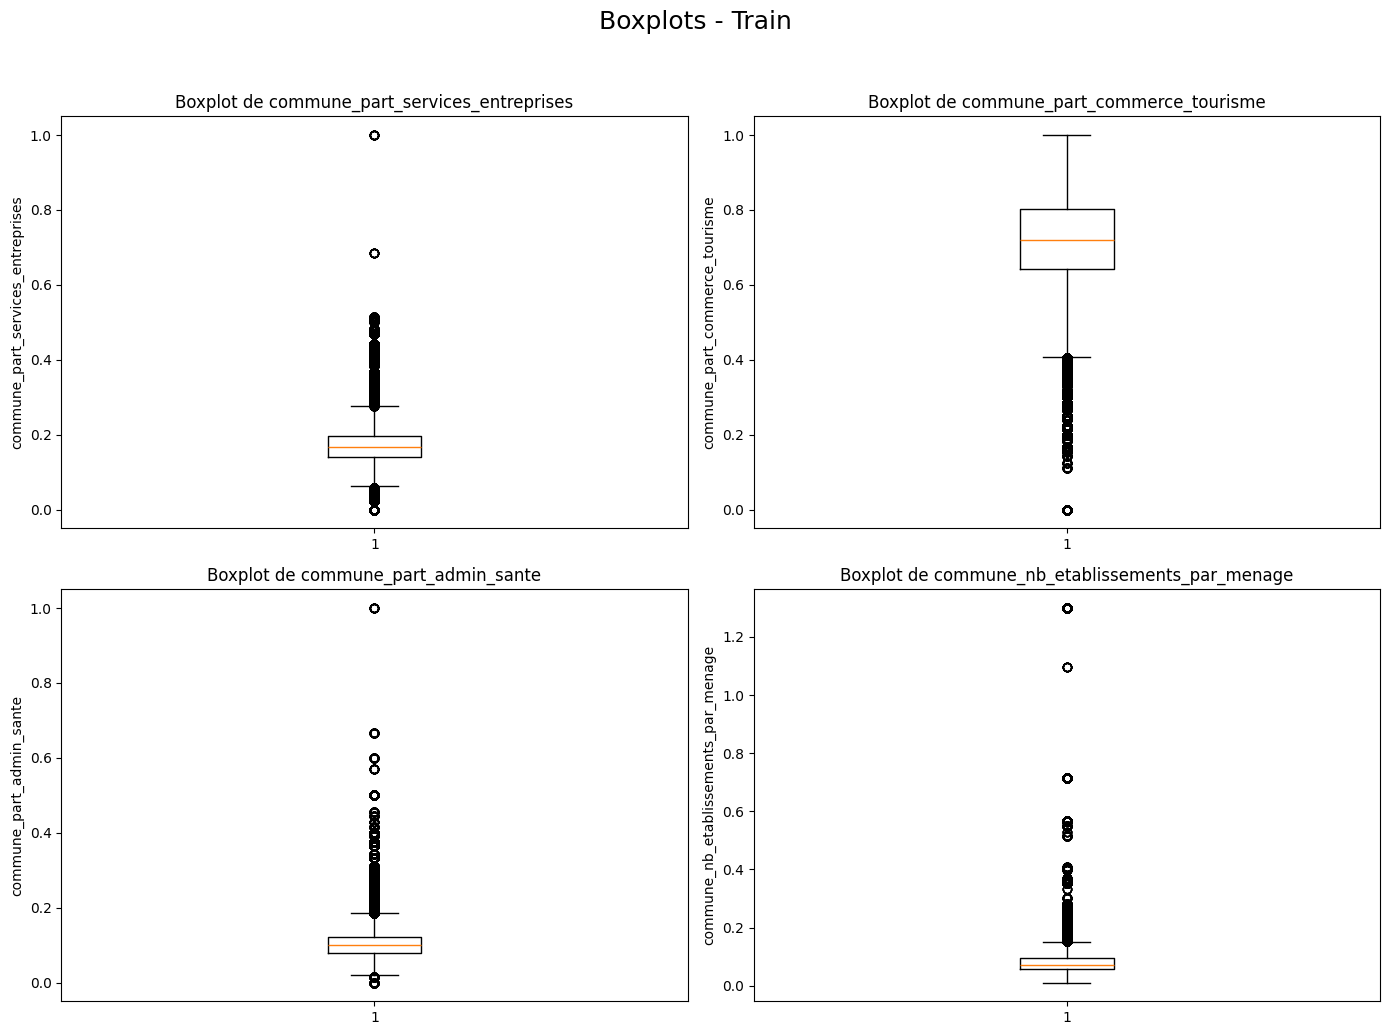

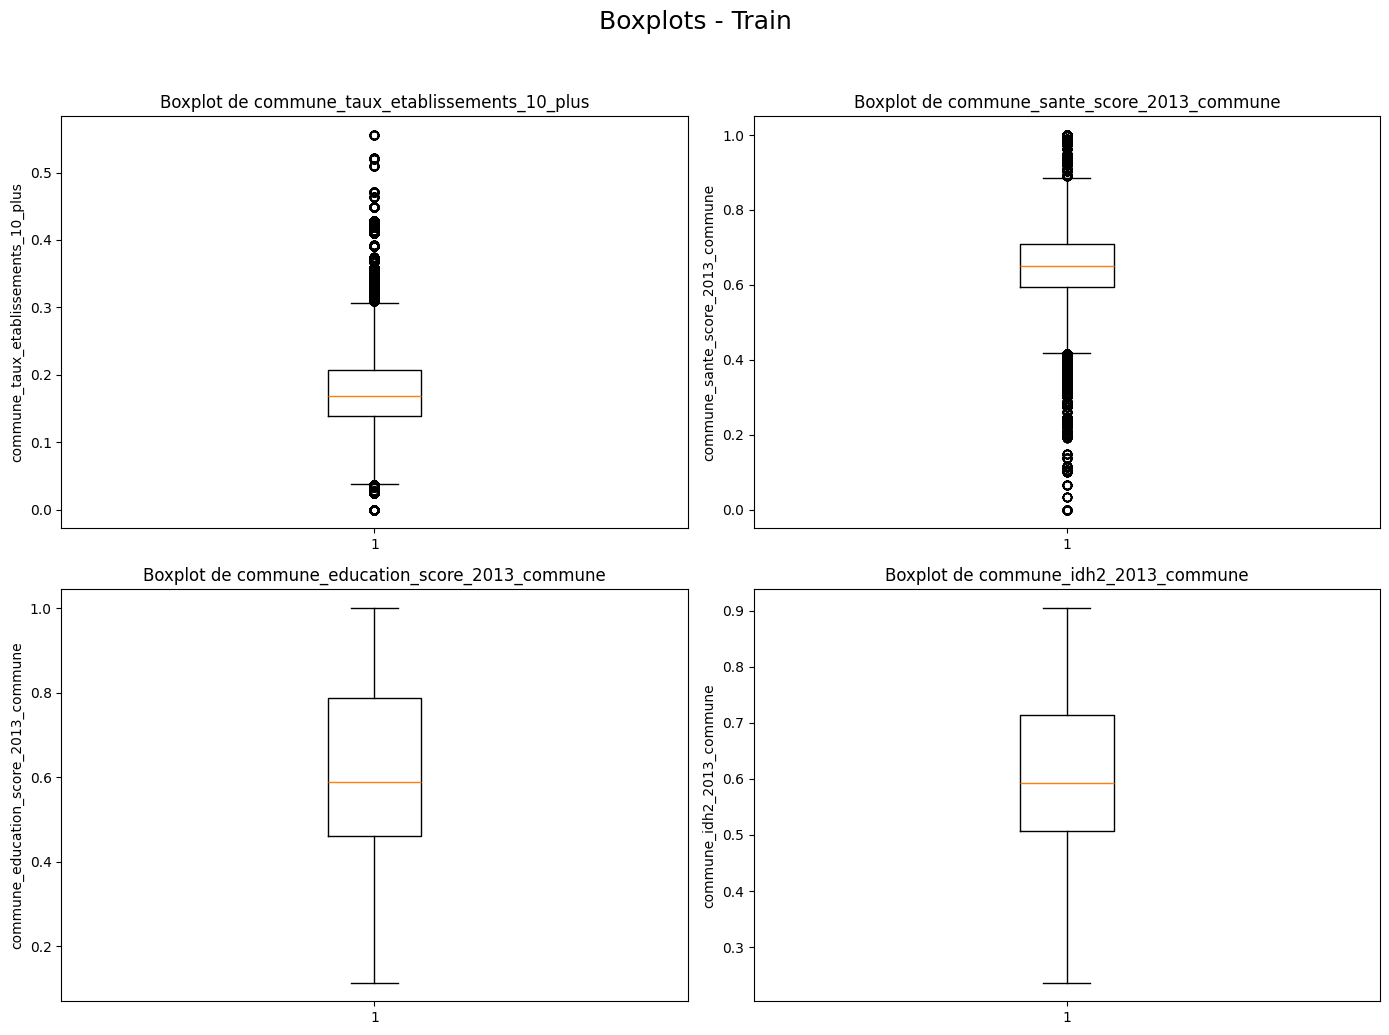

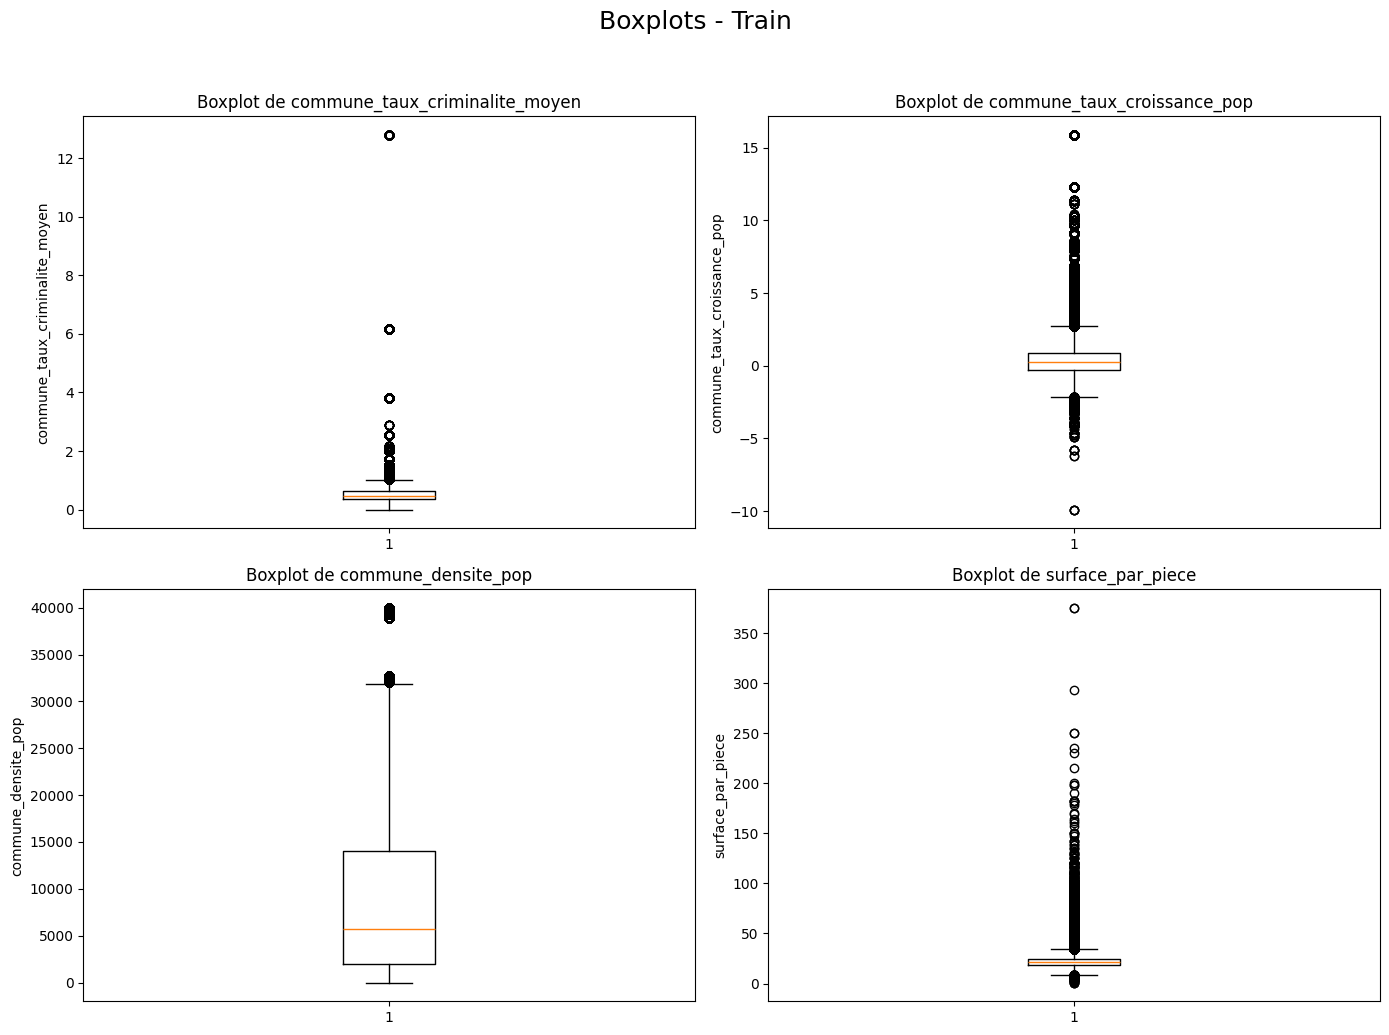

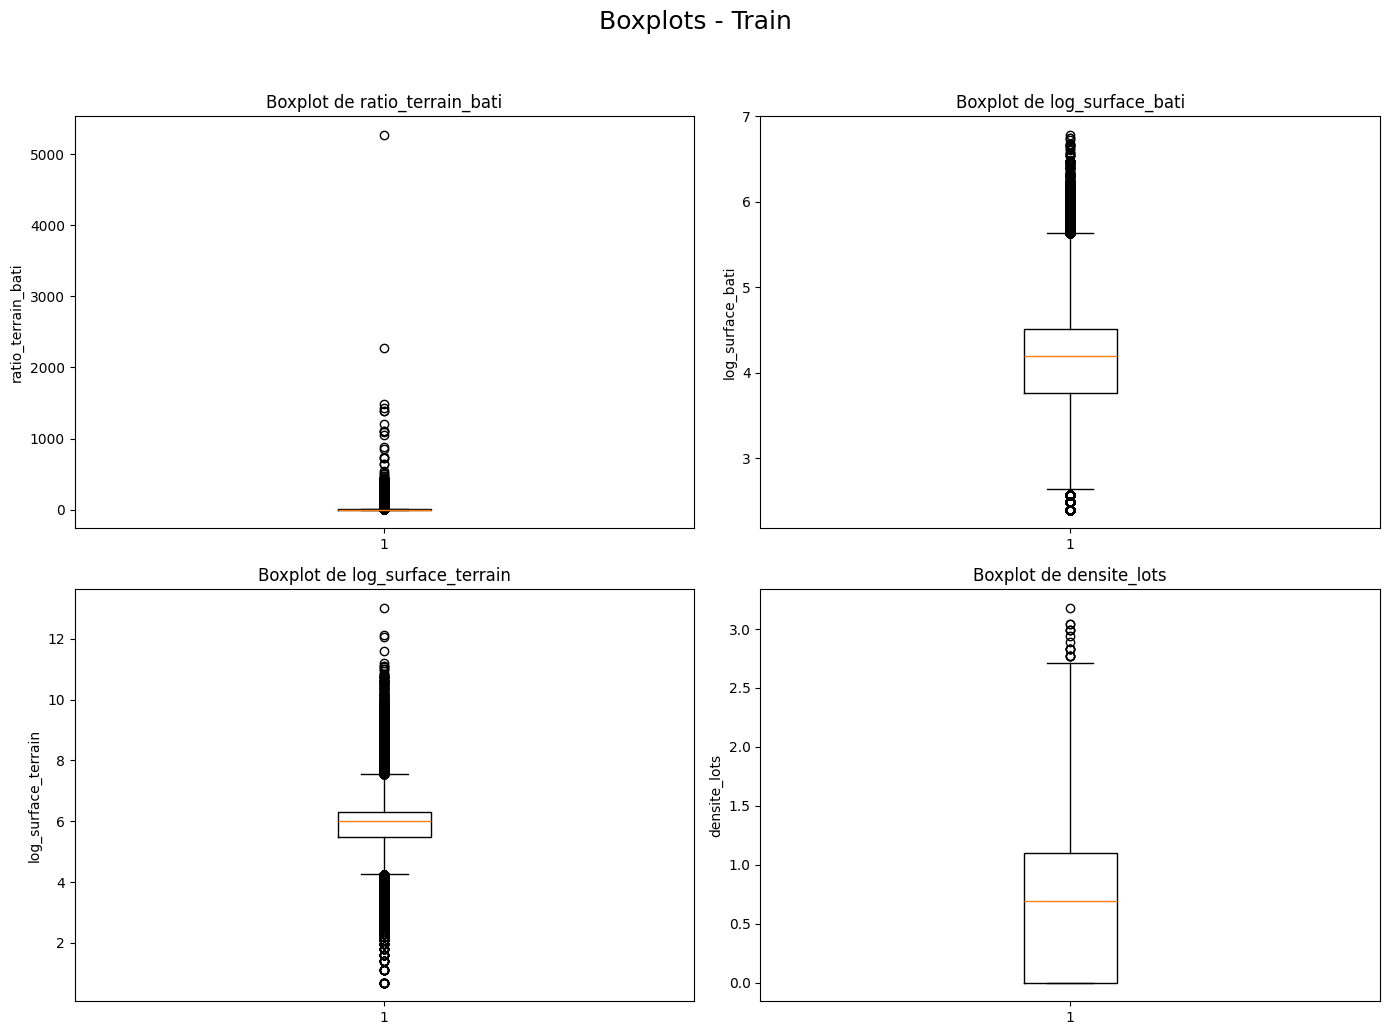

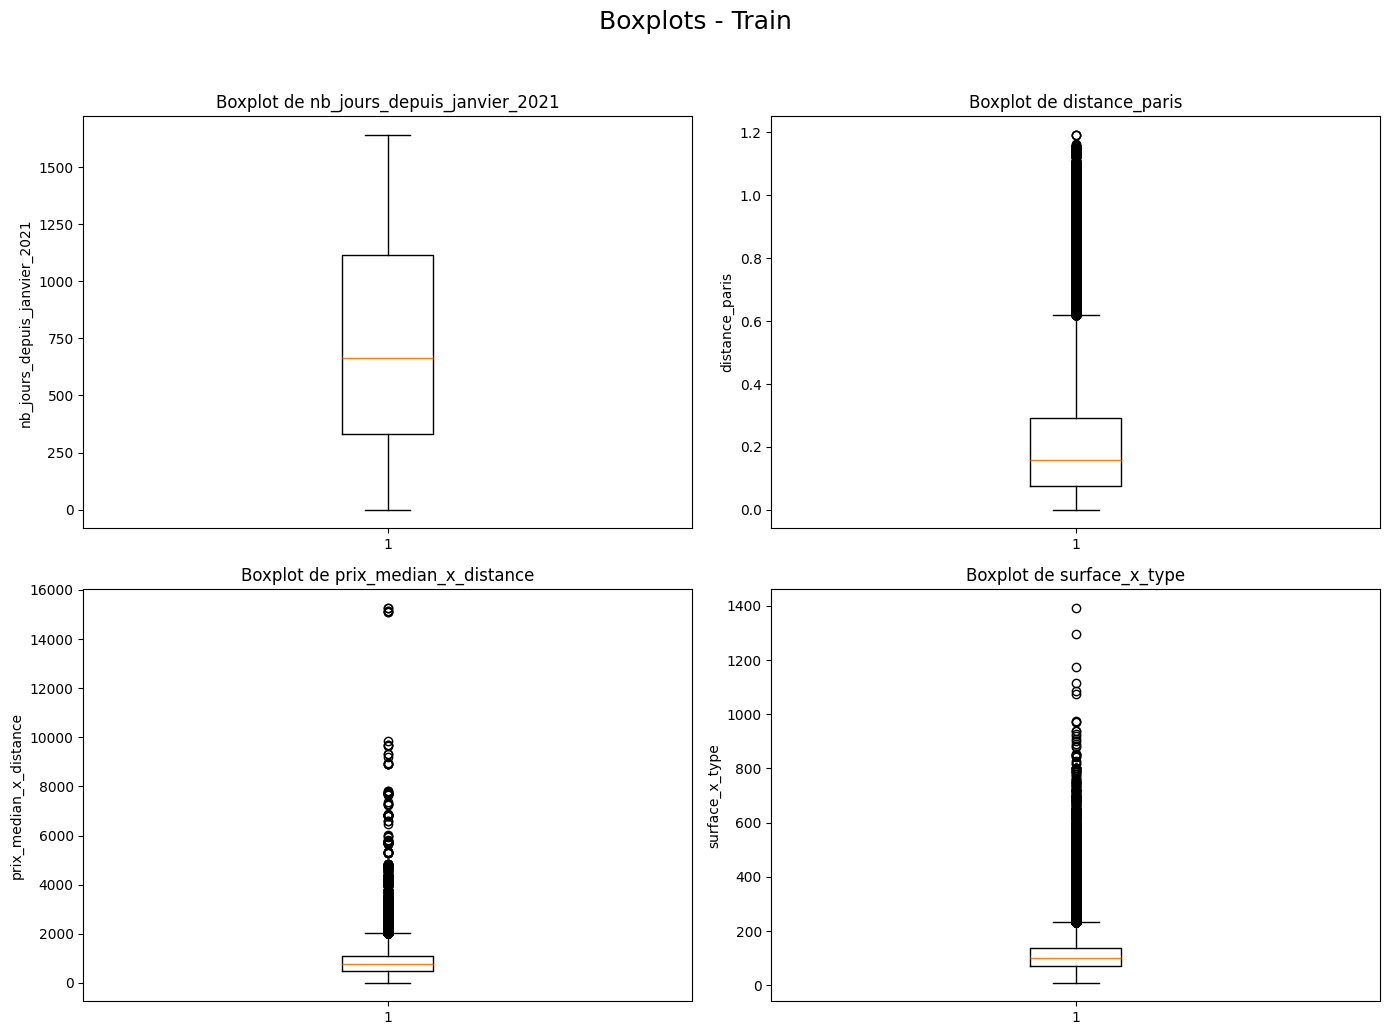

In [30]:
avqt.visualiser_par_batch(train.drop("prix_m2", axis=1),
                        train["prix_m2"], 
                        [col for col in train.select_dtypes(include=np.number).columns.tolist() if col != "prix_m2"],
                        avqt.plot_boxplot, 
                        "Boxplots - Train")

#### Nuages de points 

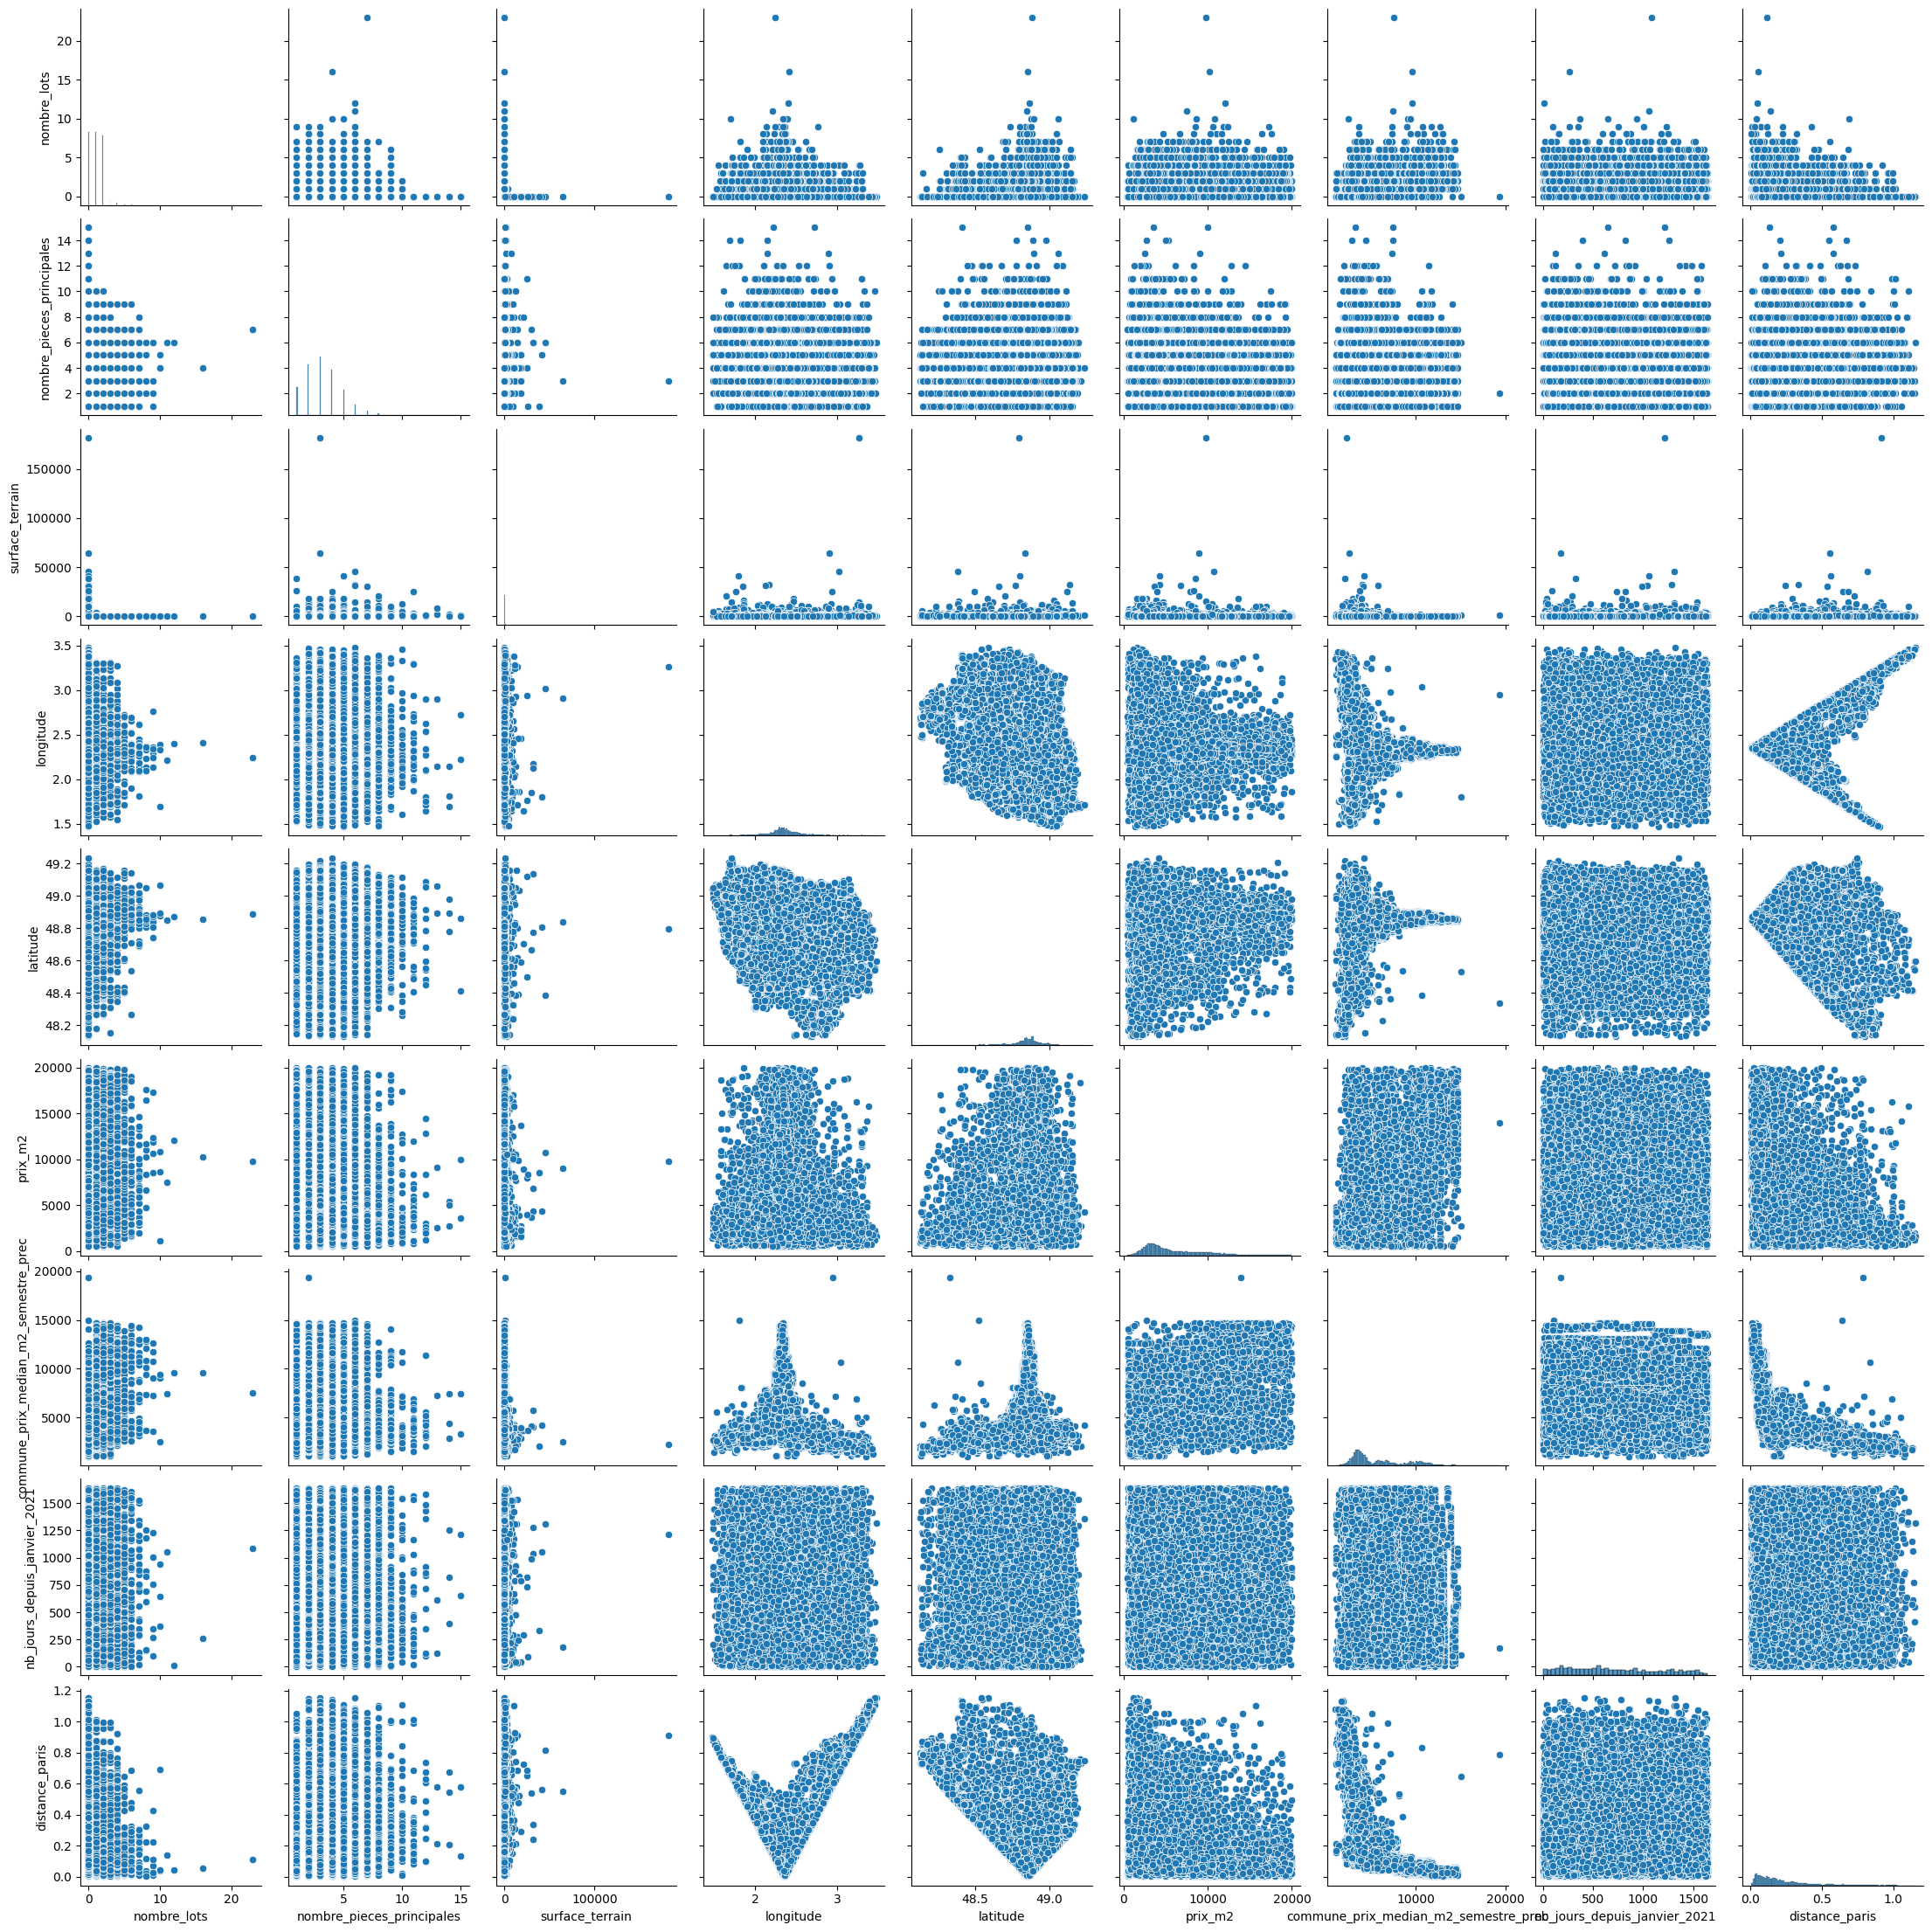

In [31]:
sns.pairplot(train[['nombre_lots',
 'nombre_pieces_principales',
 'surface_terrain',
 'longitude',
 'latitude',
 'prix_m2',
 'commune_prix_median_m2_semestre_prec',
 'nb_jours_depuis_janvier_2021',
 'distance_paris']].sample(frac=0.1, random_state=42))

#### Corrélations

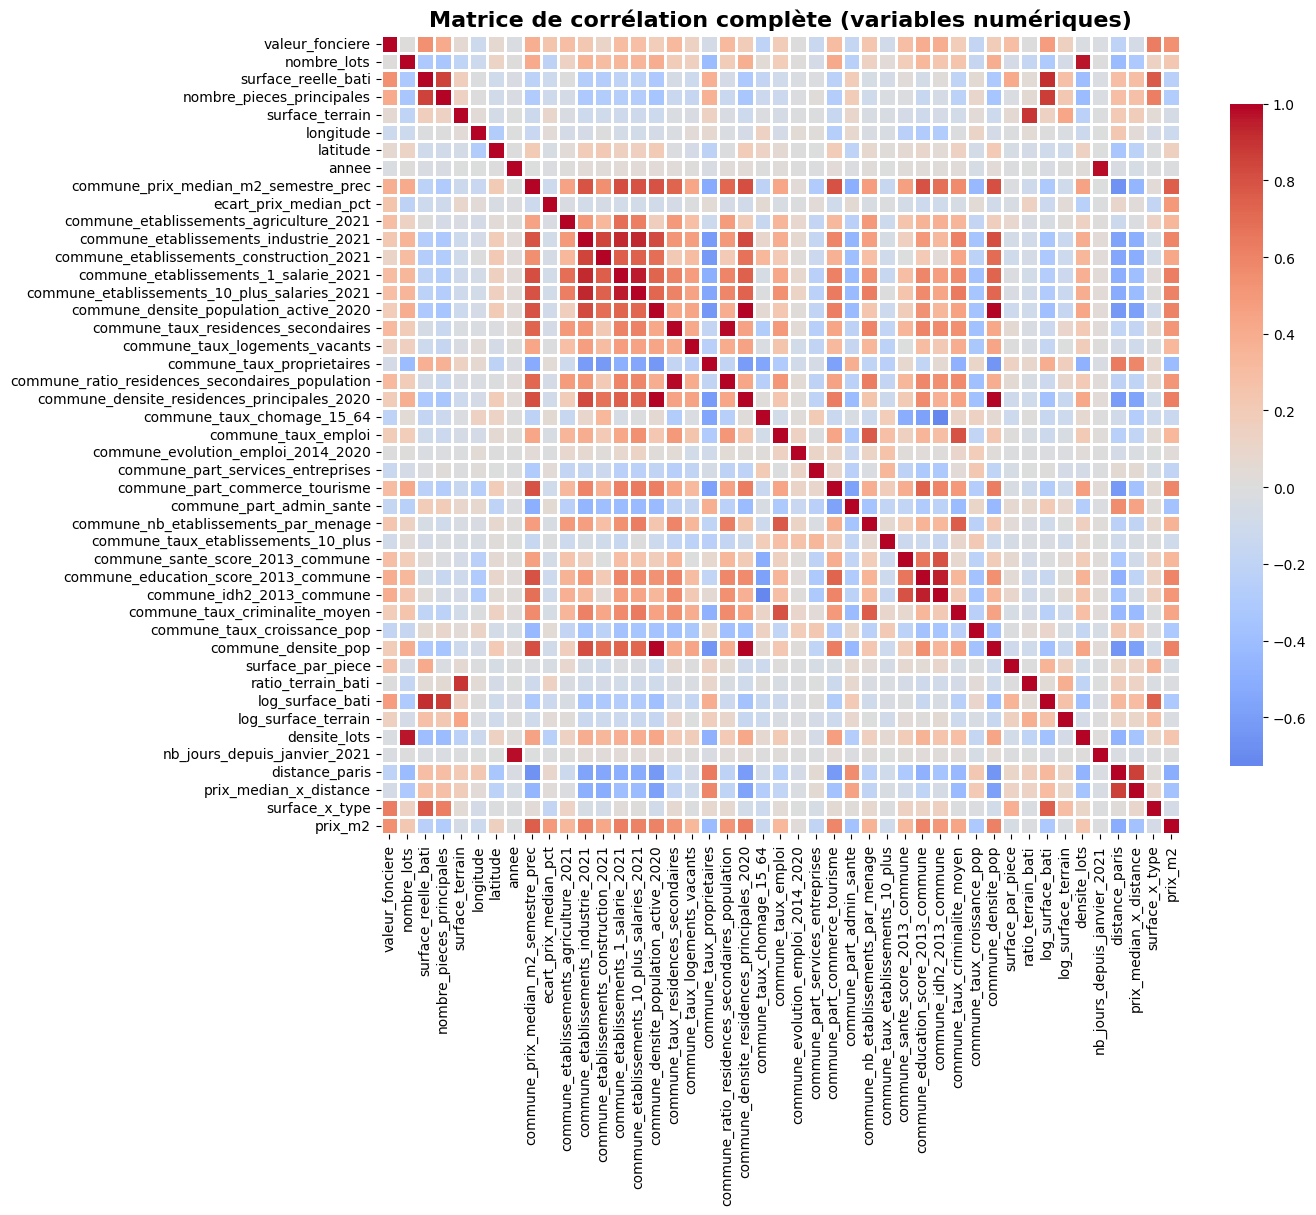

In [32]:
avqt.visualiser_matrice_correlation(train.drop("prix_m2", axis=1),
                                    train["prix_m2"], 
                                    [col for col in train.select_dtypes(include=np.number).columns.tolist() if col != "prix_m2"],
                                    annot = False)

#### Evolution du prix au mètre carré par trimestre 

In [33]:
# Calculer le prix médian et moyen par trimestre
evolution_prix = train.groupby('trimestre')['prix_m2'].agg(['count', 'median', 'mean']).reset_index()
evolution_prix.columns = ['trimestre', 'nombre_transactions', 'prix_median_m2', 'prix_moyen_m2']

# Graphique 1 : Prix médian et moyen au m² par trimestre
fig_prix = go.Figure()
fig_prix.add_trace(go.Scatter(
    x=evolution_prix['trimestre'],
    y=evolution_prix['prix_median_m2'],
    mode='lines+markers',
    name='Prix médian au m²'
))
fig_prix.add_trace(go.Scatter(
    x=evolution_prix['trimestre'],
    y=evolution_prix['prix_moyen_m2'],
    mode='lines+markers',
    name='Prix moyen au m²'
))
fig_prix.update_layout(
    title="Évolution du prix médian et moyen au m² par trimestre",
    xaxis_title="trimestre",
    yaxis_title="Prix au m² (€)",
    hovermode='x unified',
    legend_title='Indicateur',
    height=400,
    font=dict(size=12)
)
fig_prix.show()

# Graphique 2 : Nombre de transactions par trimestre
fig_tx = go.Figure()
fig_tx.add_trace(go.Scatter(
    x=evolution_prix['trimestre'],
    y=evolution_prix['nombre_transactions'],
    mode='lines+markers',
    name='Nombre de transactions'
))
fig_tx.update_layout(
    title="Nombre de transactions par trimestre",
    xaxis_title="trimestre",
    yaxis_title="Nombre de transactions",
    hovermode='x unified',
    height=400,
    font=dict(size=12)
)
fig_tx.show()

C:\Users\leoco\AppData\Local\Temp\ipykernel_23864\1663386363.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [34]:
serie_inflation = pd.read_csv("data/raw/series_macro/indice_prix_conso.csv", sep=";")
serie_inflation = serie_inflation.drop(columns="Codes")
serie_inflation = serie_inflation.drop(index=[0, 1, 2])
serie_inflation["Libellé"] = pd.to_datetime(serie_inflation["Libellé"], format="%Y-%m")
serie_inflation["Libellé"] = serie_inflation["Libellé"].dt.to_period('Q')
serie_inflation["Libellé"] = serie_inflation["Libellé"].astype(str).str.replace("Q1", "-T1").str.replace("Q2", "-T2").str.replace("Q3", "-T3").str.replace("Q4", "-T4")
serie_inflation.head(3)

,Libellé,Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Alimentation
3,2025-T4,133.48
4,2025-T3,133.79
5,2025-T3,134.05


In [35]:
evolution_prix.head(3)

,trimestre,nombre_transactions,prix_median_m2,prix_moyen_m2
0,2021-T1,30920,4519.230957,5886.012207
1,2021-T2,37430,4500.000000,5880.993652
2,2021-T3,43510,4576.470703,5916.107910


In [36]:
merged_df = pd.merge(
    evolution_prix,
    serie_inflation,
    left_on='trimestre',
    right_on='Libellé',
    how='left'
)

merged_df = merged_df[["trimestre", "prix_median_m2", "Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Alimentation"]]
merged_df.head(3)

,trimestre,prix_median_m2,Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Alimentation
0,2021-T1,4519.230957,108.24
1,2021-T1,4519.230957,108.19
2,2021-T1,4519.230957,108.4


In [37]:
fig_compare = go.Figure()

# Axe 1 : prix_median_m2
fig_compare.add_trace(go.Scatter(
    x=merged_df['trimestre'],
    y=merged_df['prix_median_m2'],
    name='Prix médian au m²',
    mode='lines+markers',
    yaxis='y1'
))

# Axe 2 : Indice des prix à la consommation
fig_compare.add_trace(go.Scatter(
    x=merged_df['trimestre'],
    y=merged_df['Indice des prix à la consommation - Base 2015 - Ensemble des ménages - France - Alimentation'],
    name='Indice des prix à la consommation',
    mode='lines+markers',
    yaxis='y2'
))

fig_compare.update_layout(
    title="Comparaison Prix médian au m² et Indice des prix à la consommation",
    xaxis=dict(title="Trimestre"),
    yaxis=dict(
        title="Prix médian au m² (€)",
        side='left'
    ),
    yaxis2=dict(
        title="Indice des prix à la consommation",
        overlaying='y',
        side='right'
    ),
    legend=dict(x=0.01, y=0.99),
    height=500,
    font=dict(size=12)
)

fig_compare.show()

# 3. Analyse des variables catégorielles 

# 4. Focus sur la variable cible 

In [38]:
fig_box = px.box(
    train, 
    y="prix_m2", 
    points="suspectedoutliers",  # show only suspected outliers
    title="Distribution du prix au m² (avec outliers)"
)
fig_box.update_layout(
    height=500,
    yaxis_title="Prix au m² (€)",
    font=dict(size=14)
)
# Optionally, zoom on the main distribution (e.g., 1st to 99th percentile)
fig_box.update_yaxes(range=[
    train["prix_m2"].quantile(0.01), 
    train["prix_m2"].quantile(0.99)
])
fig_box.show()

D'après se loger, le prix au metre carré en ile de France est compris entre :
- Prix bas : 1 662 €
- Prix haut : 14 879 €  

On va le confirmer par nos analyses :


In [39]:
mask_high_prices = train['prix_m2'] > 15000
suspicious_high_values_df = train[mask_high_prices]
suspicious_high_values_df

,date_mutation,valeur_fonciere,adresse_nom_voie,code_postal,code_commune,nom_commune,code_departement,nombre_lots,code_type_local,type_local,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
39,2024-09-12,770000.0,BD RAYMOND POINCARE,94170.0,94058,Le Perreux-sur-Marne,94,0,1.0,Maison,...,5.030438,0.000000,1350,0.142817,0,1,1,0,794.755615,49
49,2024-07-25,3000000.0,BD DU CHATEAU,92200.0,92051,Neuilly-sur-Seine,92,2,2.0,Appartement,...,NaN,1.098612,1301,0.093020,1,0,0,1,968.326355,374
106,2022-09-29,2260000.0,RUE CROIX DES PETITS CHAMPS,75001.0,75101,Paris 1er Arrondissement,75,2,2.0,Appartement,...,NaN,1.098612,636,0.013822,1,0,0,1,177.705139,266
110,2021-12-16,990000.0,RUE JEAN FONTENELLE,77210.0,77014,Avon,77,0,2.0,Appartement,...,7.299121,0.000000,349,0.586031,0,1,1,0,1630.694824,100
124,2022-07-22,700000.0,IMP DES SAPINS,94500.0,94017,Champigny-sur-Marne,94,0,2.0,Appartement,...,6.086775,0.000000,567,0.151825,0,1,1,0,644.743958,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537922,2022-04-01,925000.0,RUE CARNOT,92100.0,92012,Boulogne-Billancourt,92,2,2.0,Appartement,...,NaN,1.098612,455,0.112857,0,0,1,1,1072.144775,102
537953,2021-03-02,1450000.0,RUE JULES FERRY,92130.0,92040,Issy-les-Moulineaux,92,0,1.0,Maison,...,5.313206,0.000000,60,0.091515,0,0,1,1,808.013000,80
537968,2022-12-15,1061615.0,RUE SAINTE GENEVIEVE,94150.0,94065,Rungis,94,1,2.0,Appartement,...,NaN,0.693147,713,0.109078,0,0,1,1,502.295929,140
538036,2021-07-23,420000.0,RUE DE SEVRES,75006.0,75106,Paris 6e Arrondissement,75,2,2.0,Appartement,...,NaN,1.098612,203,0.026980,0,0,1,1,387.618683,46


In [40]:
suspicious_high_values_df["ecart_prix_median_pct"].describe()

count    13508.000000
mean       142.448074
std        154.588882
min          2.102079
25%         36.511768
50%         66.256599
75%        203.468613
max        998.010864
Name: ecart_prix_median_pct, dtype: float64

Les biens ayant un prix au mètre carré supérieurs à 15 000 euros sont en moyenne 140% plus hauts que le prix médian de leur commune. Et plus haut de 66% en médiane. 

In [41]:
mask_low_prices = train['prix_m2'] < 1500
suspicious_low_values_df = train[mask_low_prices]
suspicious_low_values_df

,date_mutation,valeur_fonciere,adresse_nom_voie,code_postal,code_commune,nom_commune,code_departement,nombre_lots,code_type_local,type_local,...,log_surface_terrain,densite_lots,nb_jours_depuis_janvier_2021,distance_paris,nord_paris,est_paris,sud_paris,ouest_paris,prix_median_x_distance,surface_x_type
63,2022-09-17,45000.0,RUE DU GEN PATTON,78980.0,78107,Bréval,78,0,1.0,Maison,...,6.406880,0.000000,624,0.822589,1,0,0,1,2427.145996,60
130,2023-02-28,18000.0,RUE ALBERT,75013.0,75113,Paris 13e Arrondissement,75,1,2.0,Appartement,...,NaN,0.693147,788,0.038421,0,1,1,0,374.891052,60
159,2021-11-25,280000.0,RUE DU GENERAL LECLERC,91490.0,91463,Oncy-sur-École,91,0,1.0,Maison,...,6.393591,0.000000,328,0.489790,0,1,1,0,1513.183472,188
232,2023-01-16,20000.0,RUE RAYMOND POINCARE,92000.0,92050,Nanterre,92,1,2.0,Appartement,...,NaN,0.693147,745,0.164594,1,0,0,1,973.136841,36
300,2022-10-11,100000.0,AV DE MADRID,92200.0,92051,Neuilly-sur-Seine,92,3,2.0,Appartement,...,NaN,1.386294,648,0.095622,1,0,0,1,1065.303101,196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537735,2024-10-03,52640.0,RUE LA FONTAINE,92120.0,92049,Montrouge,92,4,2.0,Appartement,...,NaN,1.609438,1371,0.056730,0,0,1,1,420.629547,102
537815,2024-12-06,88866.0,RUE PIERRE MECHAIN,77127.0,77251,Lieusaint,77,1,2.0,Appartement,...,NaN,0.693147,1435,0.303867,0,1,1,0,1002.759949,122
537866,2021-02-12,83000.0,RUE DES CHAUDINS,77140.0,77333,Nemours,77,0,1.0,Maison,...,5.733341,0.000000,42,0.692243,0,1,1,0,1412.570190,74
537927,2023-05-25,129343.0,RUE GRANDE,77140.0,77302,Montcourt-Fromonville,77,0,1.0,Maison,...,6.216606,0.000000,874,0.654465,0,1,1,0,1770.413086,88


In [42]:
suspicious_low_values_df["ecart_prix_median_pct"].describe()

count    9847.000000
mean      -63.413673
std        19.134237
min       -96.338463
25%       -77.662842
50%       -63.937283
75%       -52.226177
max        36.453899
Name: ecart_prix_median_pct, dtype: float64

Les biens ayant un prix au mètre carré inférieur à 1 500 euros sont en moyenne 63% plus faibles que le prix médian de leur commune. Et plus haut de 66% en médiane. 

On veut un modèle performant en moyenne plutôt que sur des valeurs excentriques. On va se passer de ces observations. 

In [43]:
print(train.shape)
train = train[(~mask_high_prices) & (~mask_low_prices)]
print(train.shape)

(538199, 60)
(513717, 60)
